In [1]:
!git clone https://github.com/niaz1971/GARBAGE_CLASSIFICATION.git

Cloning into 'GARBAGE_CLASSIFICATION'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 3.72 MiB | 8.79 MiB/s, done.


In [2]:
cd GARBAGE_CLASSIFICATION/

/content/GARBAGE_CLASSIFICATION


In [3]:
!ls

garbage_collection.ipynb  kaggle.json


In [4]:
!pip install lime kaggle
# Step 2: Set up Kaggle API for dataset download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=6ad7bd093334fa39023f35c9ad1868f47ccfac93b51d52337d1b6ba90f572ea2
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [5]:
!ls

garbage_collection.ipynb  kaggle.json


In [6]:
!kaggle datasets download -d mostafaabla/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:01<00:00, 144MB/s]



In [7]:
!ls

garbage-classification.zip  garbage_collection.ipynb  kaggle.json


In [8]:
!unzip -q garbage-classification.zip

In [9]:
!ls

garbage_classification	    garbage_collection.ipynb
garbage-classification.zip  kaggle.json


In [10]:
!rm garbage-classification.zip

In [11]:
!ls

garbage_classification	garbage_collection.ipynb  kaggle.json


In [12]:
# ============================================================
# Garbage Classification | Custom Hybrid CNN vs Baselines
# Kaggle T4 GPU | TensorFlow/Keras
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.config.optimizer.set_jit(False)

import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve, average_precision_score)
warnings.filterwarnings("ignore"); tf.get_logger().setLevel("ERROR")
print(tf.__version__, tf.config.list_physical_devices("GPU"))


2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# ── 2. CONFIG ────────────────────────────────────────────────
class CFG:
    DATA   = "garbage_classification"
    OUT    = "outputs"
    CLASSES= ["battery","biological","brown-glass","cardboard","clothes",
               "green-glass","metal","paper","plastic","shoes","trash","white-glass"]
    NC     = 12
    IMG    = 224
    BS     = 32
    SEED   = 42
    LR     = 1e-3
    WD     = 1e-4
    L2     = 1e-4
    DROP   = 0.4
    SMOOTH = 0.1
    B_EP   = 20   # baseline epochs 20
    C_EP   = 5   # custom epochs 45
    AUTO   = tf.data.AUTOTUNE

os.makedirs(CFG.OUT, exist_ok=True)
random.seed(CFG.SEED); np.random.seed(CFG.SEED); tf.random.set_seed(CFG.SEED)

Total images: 15515


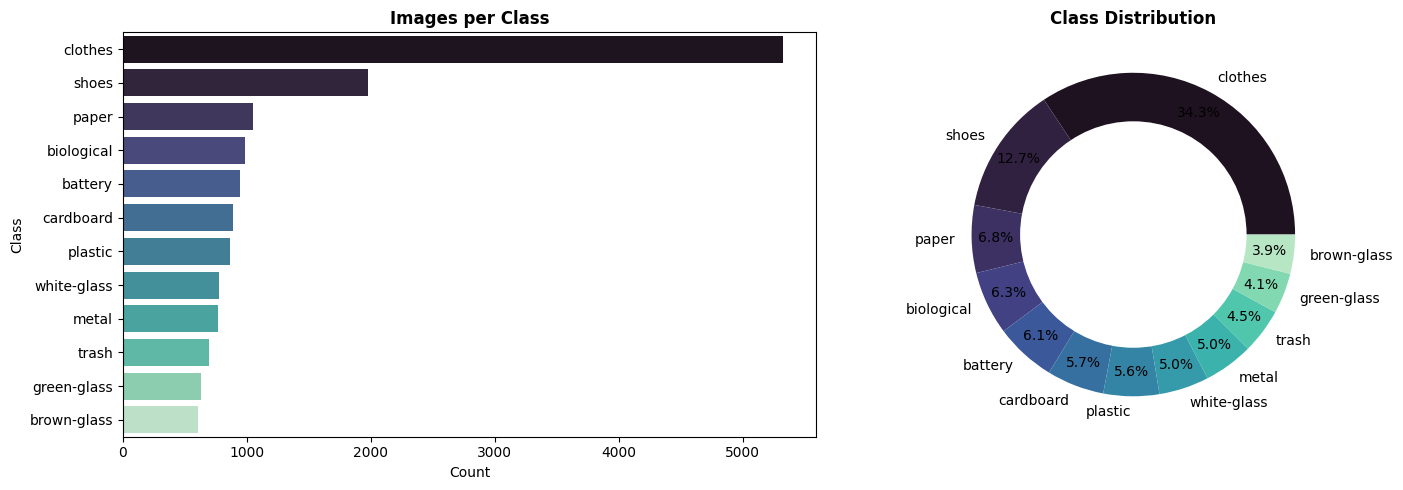

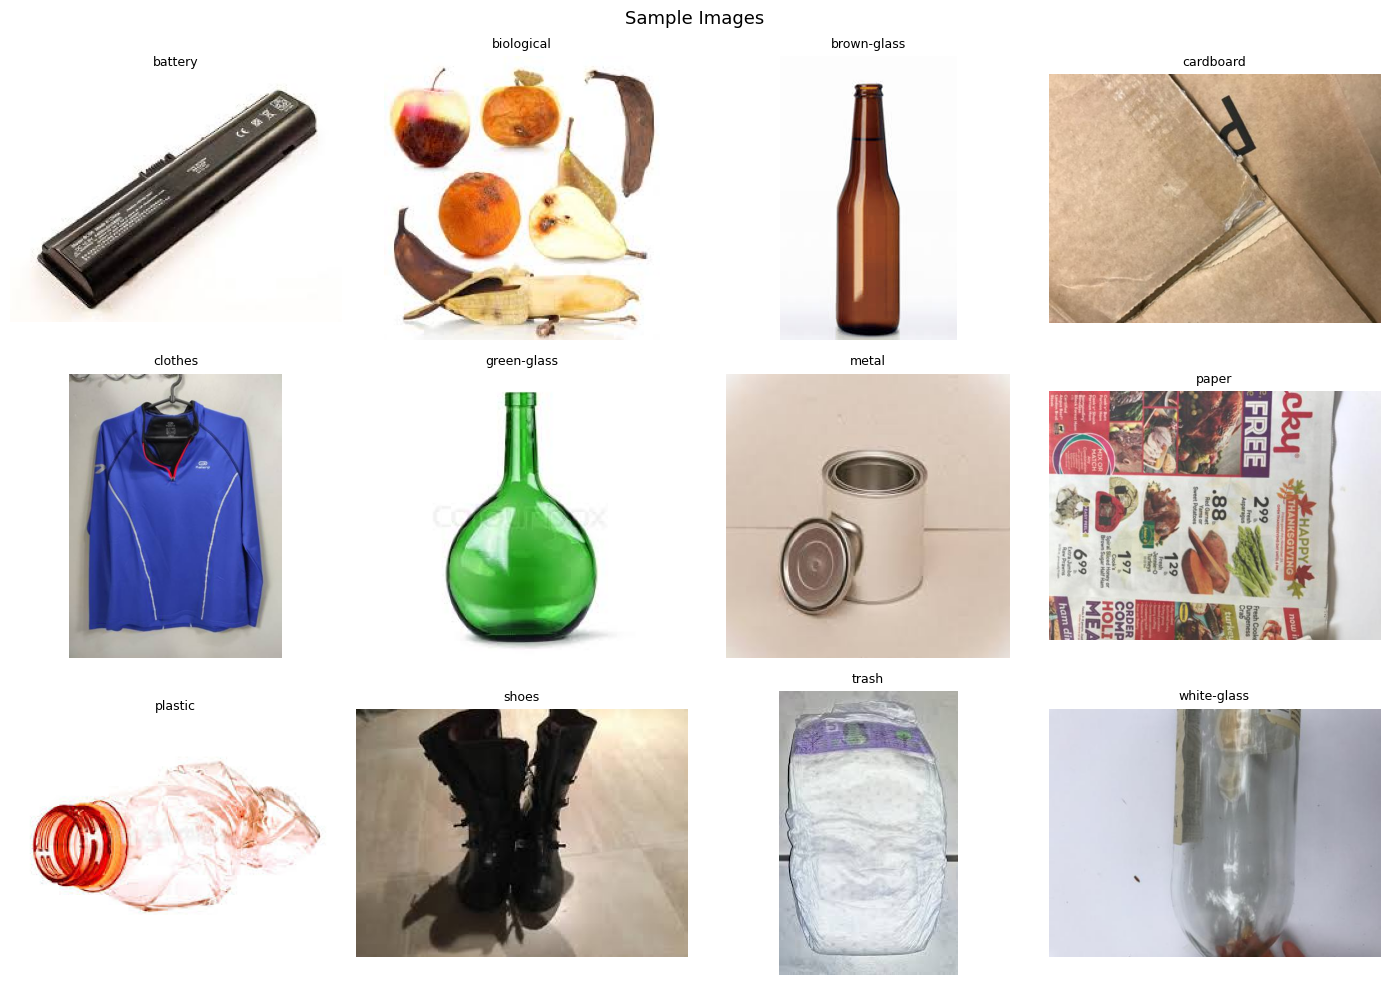

In [14]:
import os
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Dataset exploration & dataframe construction
rows = [
    (os.path.join(CFG.DATA, c, f), c, i)
    for i, c in enumerate(CFG.CLASSES)
    for f in os.listdir(os.path.join(CFG.DATA, c))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
df = pd.DataFrame(rows, columns=["path", "label", "label_idx"])
print(f"Total images: {len(df)}")

# 2. Compute class distribution
dist = df["label"].value_counts().reset_index()
dist.columns = ["Class", "Count"]

# 3. Distribution plots ('mako' palette)
colors = sns.color_palette("mako", len(dist))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
sns.barplot(
    data=dist,
    x="Count",
    y="Class",
    palette="mako",
    hue="Class",
    legend=False,
    ax=a1,
)
a1.set_title("Images per Class", fontsize=12, fontweight="bold")

# Donut chart
a2.pie(
    dist["Count"],
    labels=dist["Class"],
    autopct="%1.1f%%",
    colors=colors,
    pctdistance=0.85,
)
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
a2.add_artist(centre_circle)
a2.set_title("Class Distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{CFG.OUT}/class_dist.png", dpi=120)
plt.show()

# 4. Sample images grid
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, cls in zip(axes.flatten(), CFG.CLASSES):
    ax.imshow(plt.imread(random.choice(df[df.label == cls].path.values)))
    ax.set_title(cls, fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.savefig(f"{CFG.OUT}/samples.png", dpi=120)
plt.show()

In [15]:
# ── 4. STRATIFIED SPLIT ──────────────────────────────────────
train_df, tmp = train_test_split(df, test_size=0.30, stratify=df.label_idx, random_state=CFG.SEED)
val_df,  test_df = train_test_split(tmp, test_size=0.50, stratify=tmp.label_idx, random_state=CFG.SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train:{len(train_df)} Val:{len(val_df)} Test:{len(test_df)}")

Train:10860 Val:2327 Test:2328


In [16]:
# ── 5. CLASS WEIGHTS ─────────────────────────────────────────
cw_arr = compute_class_weight("balanced", classes=np.arange(CFG.NC), y=train_df.label_idx.values)
class_weights = {i:w for i,w in enumerate(cw_arr)}

In [17]:
# ── 6. DATA PIPELINE ─────────────────────────────────────────
def load_img(path, label):
    img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, [CFG.IMG, CFG.IMG])
    return tf.cast(img, tf.float32) / 255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    scale = tf.random.uniform([], 0.85, 1.0)
    crop  = tf.cast(tf.cast(CFG.IMG, tf.float32) * scale, tf.int32)
    img   = tf.image.random_crop(img, [crop, crop, 3])
    img   = tf.image.resize(img, [CFG.IMG, CFG.IMG])
    return tf.clip_by_value(img, 0.0, 1.0), label

def make_ds(frame, aug=False, shuffle=False):
    labels = tf.keras.utils.to_categorical(frame.label_idx.values, CFG.NC)
    ds = tf.data.Dataset.from_tensor_slices((frame.path.values, labels))
    if shuffle: ds = ds.shuffle(len(frame), seed=CFG.SEED)
    ds = ds.map(load_img, num_parallel_calls=CFG.AUTO)
    if aug: ds = ds.map(augment, num_parallel_calls=CFG.AUTO)
    return ds.batch(CFG.BS).prefetch(CFG.AUTO)

train_ds = make_ds(train_df, aug=True,  shuffle=True)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)

In [18]:
# ── 7. FOCAL LOSS ────────────────────────────────────────────
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, smoothing=CFG.SMOOTH):
        super().__init__()
        self.gamma, self.alpha, self.smoothing = gamma, alpha, smoothing

    def call(self, y_true, y_pred):
        y_true = y_true*(1-self.smoothing) + self.smoothing/CFG.NC
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        fl = self.alpha * tf.pow(1-y_pred, self.gamma) * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))

std_loss  = CategoricalCrossentropy(label_smoothing=CFG.SMOOTH)
focal_loss= FocalLoss()

In [19]:
# ── 8. HELPERS ───────────────────────────────────────────────
def cosine_opt(lr=CFG.LR, epochs=CFG.B_EP):
    sched = tf.keras.optimizers.schedules.CosineDecay(
        lr, decay_steps=(len(train_df)//CFG.BS)*epochs, alpha=1e-6)
    return AdamW(sched, weight_decay=CFG.WD, clipnorm=1.0)

def callbacks(name):
    return [
        EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True),
        ModelCheckpoint(f"{CFG.OUT}/{name}_best.keras", save_best_only=True, monitor="val_accuracy"),
        CSVLogger(f"{CFG.OUT}/{name}_log.csv")
    ]

def plot_curves(hist, name):
    fig, (a1,a2) = plt.subplots(1,2,figsize=(13,4))
    fig.suptitle(f"Training Curves — {name}", fontweight="bold")
    for ax,(tr,va),title in zip((a1,a2),
        [(hist["accuracy"],hist["val_accuracy"]),(hist["loss"],hist["val_loss"])],
        ["Accuracy","Loss"]):
        ax.plot(tr, label="Train"); ax.plot(va,"--",label="Val")
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{CFG.OUT}/curves_{name}.png",dpi=120); plt.show()

def get_preds(model, ds):
    yt, yp = [], []
    for x,y in ds:
        yt.append(y.numpy()); yp.append(model.predict(x, verbose=0))
    return np.concatenate(yt), np.concatenate(yp)

def evaluate(model, ds, name):
    yt_oh, yp = get_preds(model, ds)
    yt, yp_cls = np.argmax(yt_oh,1), np.argmax(yp,1)
    rep = classification_report(yt, yp_cls, target_names=CFG.CLASSES, output_dict=True, zero_division=0)
    print(f"\n── {name} ──")
    print(classification_report(yt, yp_cls, target_names=CFG.CLASSES, zero_division=0))
    return yt, yp_cls, yt_oh, yp, rep

def plot_cm(yt, yp, name):
    cm = confusion_matrix(yt, yp)
    fig, axes = plt.subplots(1,2,figsize=(20,8))
    for ax, data, fmt, title in zip(axes, [cm, cm/cm.sum(1,keepdims=True)], ["d",".2f"], ["Count","Norm"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                    xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES, linewidths=0.3)
        ax.set_title(f"Confusion Matrix ({title}) — {name}", fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.savefig(f"{CFG.OUT}/cm_{name}.png",dpi=120); plt.show()

def plot_roc(yt_oh, yp, name):
    fprs, tprs, aucs = {},{},{}
    for i in range(CFG.NC):
        fprs[i], tprs[i], _ = roc_curve(yt_oh[:,i], yp[:,i])
        aucs[i] = auc(fprs[i], tprs[i])
    fig, axes = plt.subplots(3,4,figsize=(18,13))
    for i,(ax,cls) in enumerate(zip(axes.flatten(), CFG.CLASSES)):
        ax.plot(fprs[i], tprs[i], linewidth=2, label=f"AUC={aucs[i]:.3f}")
        ax.plot([0,1],[0,1],"k--"); ax.set_title(cls,fontsize=10)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(); ax.grid(alpha=0.3)
    macro_auc = np.mean(list(aucs.values()))
    plt.suptitle(f"ROC Curves — {name} | Macro AUC={macro_auc:.3f}", fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{CFG.OUT}/roc_{name}.png",dpi=120); plt.show()
    return macro_auc

def plot_pr(yt_oh, yp, name):
    fig, axes = plt.subplots(3,4,figsize=(18,13))
    for i,(ax,cls) in enumerate(zip(axes.flatten(), CFG.CLASSES)):
        p, r, _ = precision_recall_curve(yt_oh[:,i], yp[:,i])
        ap = average_precision_score(yt_oh[:,i], yp[:,i])
        ax.plot(r, p, linewidth=2, label=f"AP={ap:.3f}")
        ax.set_title(cls,fontsize=10); ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f"Precision-Recall Curves — {name}", fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{CFG.OUT}/pr_{name}.png",dpi=120); plt.show()

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# ── GLOBAL LIGHT THEME CONFIGURATION ──────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

# Custom light theme settings
BG_COLOR = "#FFFFFF"  # Pure white figure & axes background
TEXT_COLOR = "#1A1A1A"  # Dark gray/black text for maximum contrast

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.facecolor": BG_COLOR,
        "axes.facecolor": BG_COLOR,
        "savefig.facecolor": BG_COLOR,
        "text.color": TEXT_COLOR,
        "axes.labelcolor": TEXT_COLOR,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "axes.edgecolor": "#CCCCCC",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


# ── 8. HELPERS ───────────────────────────────────────────────
def cosine_opt(lr=CFG.LR, epochs=CFG.B_EP):
    sched = tf.keras.optimizers.schedules.CosineDecay(
        lr, decay_steps=(len(train_df) // CFG.BS) * epochs, alpha=1e-6
    )
    return AdamW(sched, weight_decay=CFG.WD, clipnorm=1.0)


def callbacks(name):
    return [
        EarlyStopping(
            monitor="val_accuracy", patience=7, restore_best_weights=True
        ),
        ModelCheckpoint(
            f"{CFG.OUT}/{name}_best.keras",
            save_best_only=True,
            monitor="val_accuracy",
        ),
        CSVLogger(f"{CFG.OUT}/{name}_log.csv"),
    ]


def plot_curves(hist, name):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(
        f"Training Curves — {name}",
        fontweight="bold",
        fontsize=14,
        color=TEXT_COLOR,
    )

    # Clean high-contrast color pairs
    train_color, val_color = "#0066CC", "#D9381E"  # Deep Blue & Crisp Red

    for ax, (tr, va), title in zip(
        (a1, a2),
        [
            (hist["accuracy"], hist["val_accuracy"]),
            (hist["loss"], hist["val_loss"]),
        ],
        ["Accuracy", "Loss"],
    ):
        ax.plot(tr, label="Train", color=train_color, linewidth=2.2)
        ax.plot(va, label="Val", color=val_color, linestyle="--", linewidth=2.0)
        ax.set_title(title, fontweight="bold", fontsize=11, color=TEXT_COLOR)
        ax.legend(
            frameon=True,
            facecolor="#F5F5F5",
            edgecolor="none",
            labelcolor=TEXT_COLOR,
        )
        ax.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC")

    plt.tight_layout()
    plt.savefig(f"{CFG.OUT}/curves_{name}.png", dpi=120)
    plt.show()


def get_preds(model, ds):
    yt, yp = [], []
    for x, y in ds:
        yt.append(y.numpy())
        yp.append(model.predict(x, verbose=0))
    return np.concatenate(yt), np.concatenate(yp)


def evaluate(model, ds, name):
    yt_oh, yp = get_preds(model, ds)
    yt, yp_cls = np.argmax(yt_oh, 1), np.argmax(yp, 1)
    rep = classification_report(
        yt,
        yp_cls,
        target_names=CFG.CLASSES,
        output_dict=True,
        zero_division=0,
    )
    print(f"\n── {name} ──")
    print(
        classification_report(
            yt, yp_cls, target_names=CFG.CLASSES, zero_division=0
        )
    )
    return yt, yp_cls, yt_oh, yp, rep


def plot_cm(yt, yp, name):
    cm = confusion_matrix(yt, yp)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Clean, vibrant palettes for light background
    cmaps = ["Blues", "YlGnBu"]

    for ax, data, fmt, title, cmap in zip(
        axes,
        [cm, cm / cm.sum(1, keepdims=True)],
        ["d", ".2f"],
        ["Count", "Normalized"],
        cmaps,
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            ax=ax,
            xticklabels=CFG.CLASSES,
            yticklabels=CFG.CLASSES,
            linewidths=0.8,
            linecolor="#E0E0E0",
            cbar=False,
            annot_kws={"size": 10, "weight": "bold"},
        )
        ax.set_title(
            f"Confusion Matrix ({title}) — {name}",
            fontweight="bold",
            fontsize=12,
            color=TEXT_COLOR,
        )
        ax.set_xlabel("Predicted Class", fontweight="bold", color=TEXT_COLOR)
        ax.set_ylabel("Actual Class", fontweight="bold", color=TEXT_COLOR)
        ax.tick_params(axis="x", rotation=45, colors=TEXT_COLOR)
        ax.tick_params(axis="y", colors=TEXT_COLOR)

    plt.tight_layout()
    plt.savefig(f"{CFG.OUT}/cm_{name}.png", dpi=120)
    plt.show()


def plot_roc(yt_oh, yp, name):
    fprs, tprs, aucs = {}, {}, {}
    for i in range(CFG.NC):
        fprs[i], tprs[i], _ = roc_curve(yt_oh[:, i], yp[:, i])
        aucs[i] = auc(fprs[i], tprs[i])

    fig, axes = plt.subplots(3, 4, figsize=(18, 13))

    for i, (ax, cls) in enumerate(zip(axes.flatten(), CFG.CLASSES)):
        ax.plot(
            fprs[i],
            tprs[i],
            color="#0066CC",
            linewidth=2,
            label=f"AUC = {aucs[i]:.3f}",
        )
        ax.plot(
            [0, 1], [0, 1], color="#888888", linestyle="--", linewidth=1.2
        )
        ax.set_title(cls, fontsize=10, fontweight="bold", color=TEXT_COLOR)
        ax.set_xlabel("FPR", fontsize=8, color=TEXT_COLOR)
        ax.set_ylabel("TPR", fontsize=8, color=TEXT_COLOR)
        ax.legend(
            loc="lower right",
            frameon=True,
            facecolor="#F5F5F5",
            edgecolor="none",
            labelcolor=TEXT_COLOR,
        )
        ax.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC")

    macro_auc = np.mean(list(aucs.values()))
    plt.suptitle(
        f"ROC Curves — {name} | Macro AUC = {macro_auc:.3f}",
        fontweight="bold",
        fontsize=14,
        color=TEXT_COLOR,
    )
    plt.tight_layout()
    plt.savefig(f"{CFG.OUT}/roc_{name}.png", dpi=120)
    plt.show()
    return macro_auc


def plot_pr(yt_oh, yp, name):
    fig, axes = plt.subplots(3, 4, figsize=(18, 13))

    for i, (ax, cls) in enumerate(zip(axes.flatten(), CFG.CLASSES)):
        p, r, _ = precision_recall_curve(yt_oh[:, i], yp[:, i])
        ap = average_precision_score(yt_oh[:, i], yp[:, i])
        ax.plot(
            r,
            p,
            color="#2E8B57",
            linewidth=2,
            label=f"AP = {ap:.3f}",
        )  # Forest Green
        ax.set_title(cls, fontsize=10, fontweight="bold", color=TEXT_COLOR)
        ax.set_xlabel("Recall", fontsize=8, color=TEXT_COLOR)
        ax.set_ylabel("Precision", fontsize=8, color=TEXT_COLOR)
        ax.legend(
            loc="lower left",
            frameon=True,
            facecolor="#F5F5F5",
            edgecolor="none",
            labelcolor=TEXT_COLOR,
        )
        ax.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC")

    plt.suptitle(
        f"Precision-Recall Curves — {name}",
        fontweight="bold",
        fontsize=14,
        color=TEXT_COLOR,
    )
    plt.tight_layout()
    plt.savefig(f"{CFG.OUT}/pr_{name}.png", dpi=120)
    plt.show()

In [21]:
# ── 9. BASELINE MODELS ───────────────────────────────────────

# 01. Simple CNN
def simple_cnn():
    inp = layers.Input((CFG.IMG,CFG.IMG,3))
    x = inp
    for f in [32,64,128,256]:
        x = layers.Conv2D(f,3,padding="same",activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256,activation="relu",kernel_regularizer=regularizers.l2(CFG.L2))(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="SimpleCNN")

In [22]:
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras import layers, Model, regularizers

def vgg16_model():
    base = VGG16(input_shape=(CFG.IMG, CFG.IMG, 3), include_top=False, weights="imagenet")
    base.trainable = False

    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2))(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)

    return Model(inp, out, name="VGG16")

In [23]:
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras import layers, Model, regularizers

def vgg19_model():
    base = VGG19(input_shape=(CFG.IMG, CFG.IMG, 3), include_top=False, weights="imagenet")
    base.trainable = False

    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2))(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)

    return Model(inp, out, name="VGG19")

In [24]:
# 03 MobileNetV2
def mobilenet_model():
    base = MobileNetV2(input_shape=(CFG.IMG,CFG.IMG,3), include_top=False, weights="imagenet")
    base.trainable = False
    inp = layers.Input((CFG.IMG,CFG.IMG,3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256,activation="relu",kernel_regularizer=regularizers.l2(CFG.L2))(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="MobileNetV2")

In [25]:
# 04 EfficientNetB0
def efficientnet_model():
    base = EfficientNetB0(input_shape=(CFG.IMG,CFG.IMG,3), include_top=False, weights="imagenet")
    base.trainable = False
    inp = layers.Input((CFG.IMG,CFG.IMG,3))
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256,activation="relu",kernel_regularizer=regularizers.l2(CFG.L2))(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="EfficientNetB0")

In [26]:
from tensorflow.keras.applications import EfficientNetB1
def efficientnetb1_model():
    base = EfficientNetB1(input_shape=(CFG.IMG, CFG.IMG, 3), include_top=False, weights="imagenet")
    base.trainable = False
    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2))(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="EfficientNetB1")

In [27]:
from tensorflow.keras.applications import EfficientNetB2


def efficientnetb2_model():
    base = EfficientNetB2(
        input_shape=(CFG.IMG, CFG.IMG, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False
    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2)
    )(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="EfficientNetB2")

In [28]:
from tensorflow.keras.applications import EfficientNetB3


def efficientnetb3_model():
    base = EfficientNetB3(
        input_shape=(CFG.IMG, CFG.IMG, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False
    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2)
    )(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="EfficientNetB3")

In [29]:
from tensorflow.keras.applications import EfficientNetB4


def efficientnetb4_model():
    base = EfficientNetB4(
        input_shape=(CFG.IMG, CFG.IMG, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False
    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2)
    )(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="EfficientNetB4")

In [30]:
from tensorflow.keras.applications import EfficientNetB5


def efficientnetb5_model():
    base = EfficientNetB5(
        input_shape=(CFG.IMG, CFG.IMG, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False
    inp = layers.Input((CFG.IMG, CFG.IMG, 3))
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        256, activation="relu", kernel_regularizer=regularizers.l2(CFG.L2)
    )(x)
    x = layers.Dropout(CFG.DROP)(x)
    out = layers.Dense(CFG.NC, activation="softmax", dtype="float32")(x)
    return Model(inp, out, name="EfficientNetB5")


Training SimpleCNN
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 57s 119ms/step - accuracy: 0.3742 - loss: 2.0097 - val_accuracy: 0.1844 - val_loss: 2.7415
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.4592 - loss: 1.7723 - val_accuracy: 0.4766 - val_loss: 1.7471
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.5068 - loss: 1.7004 - val_accuracy: 0.4091 - val_loss: 2.0155
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.5300 - loss: 1.6460 - val_accuracy: 0.4890 - val_loss: 1.7552
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.5530 - loss: 1.5852 - val_accuracy: 0.4822 - val_loss: 1.7957
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.5889 - loss: 1.5247 - val_accuracy: 0.5582 - val_loss: 1.5888
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.6110 - loss: 1.4790 - val_accuracy: 0.6476 - val_loss: 1.3956
Epoch 8/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.6

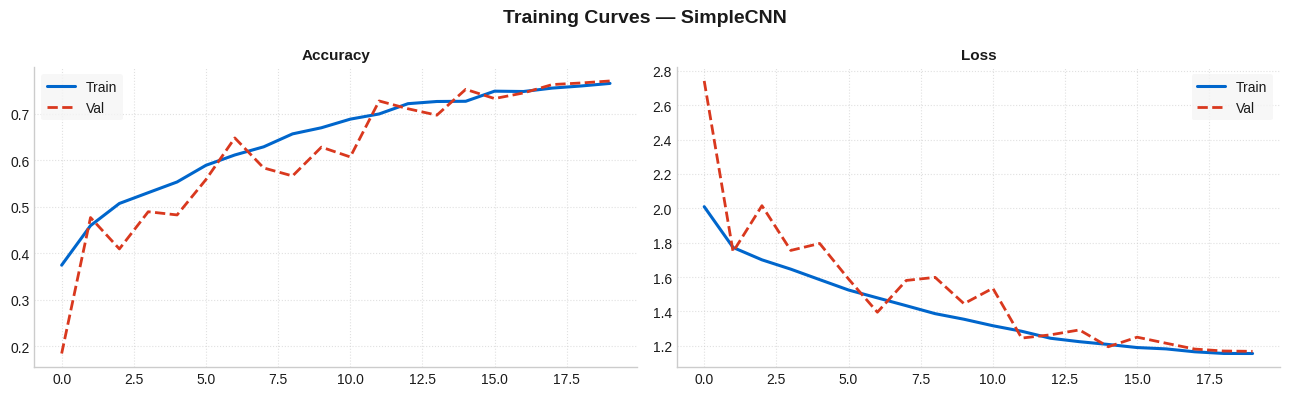


── SimpleCNN ──
              precision    recall  f1-score   support

     battery       0.80      0.72      0.76       142
  biological       0.87      0.78      0.83       148
 brown-glass       0.87      0.73      0.79        91
   cardboard       0.68      0.84      0.75       134
     clothes       0.89      0.91      0.90       799
 green-glass       0.83      0.88      0.86        94
       metal       0.52      0.72      0.61       115
       paper       0.77      0.75      0.76       158
     plastic       0.58      0.65      0.61       130
       shoes       0.78      0.53      0.63       297
       trash       0.69      0.75      0.72       104
 white-glass       0.60      0.74      0.66       116

    accuracy                           0.78      2328
   macro avg       0.74      0.75      0.74      2328
weighted avg       0.79      0.78      0.78      2328



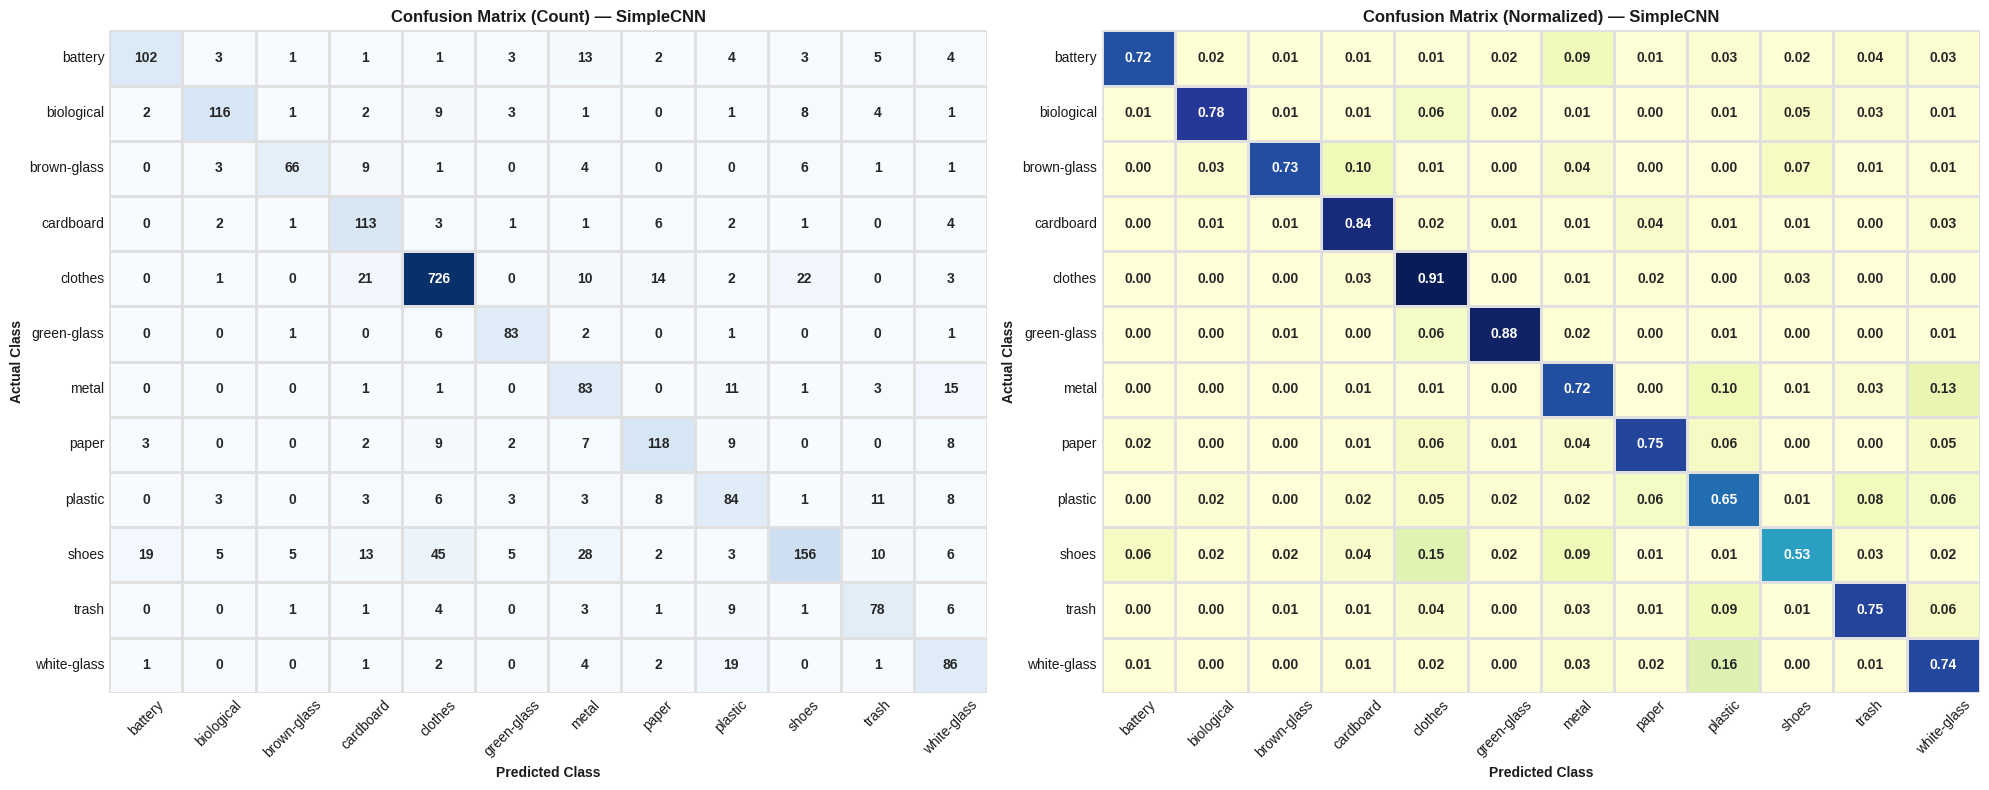

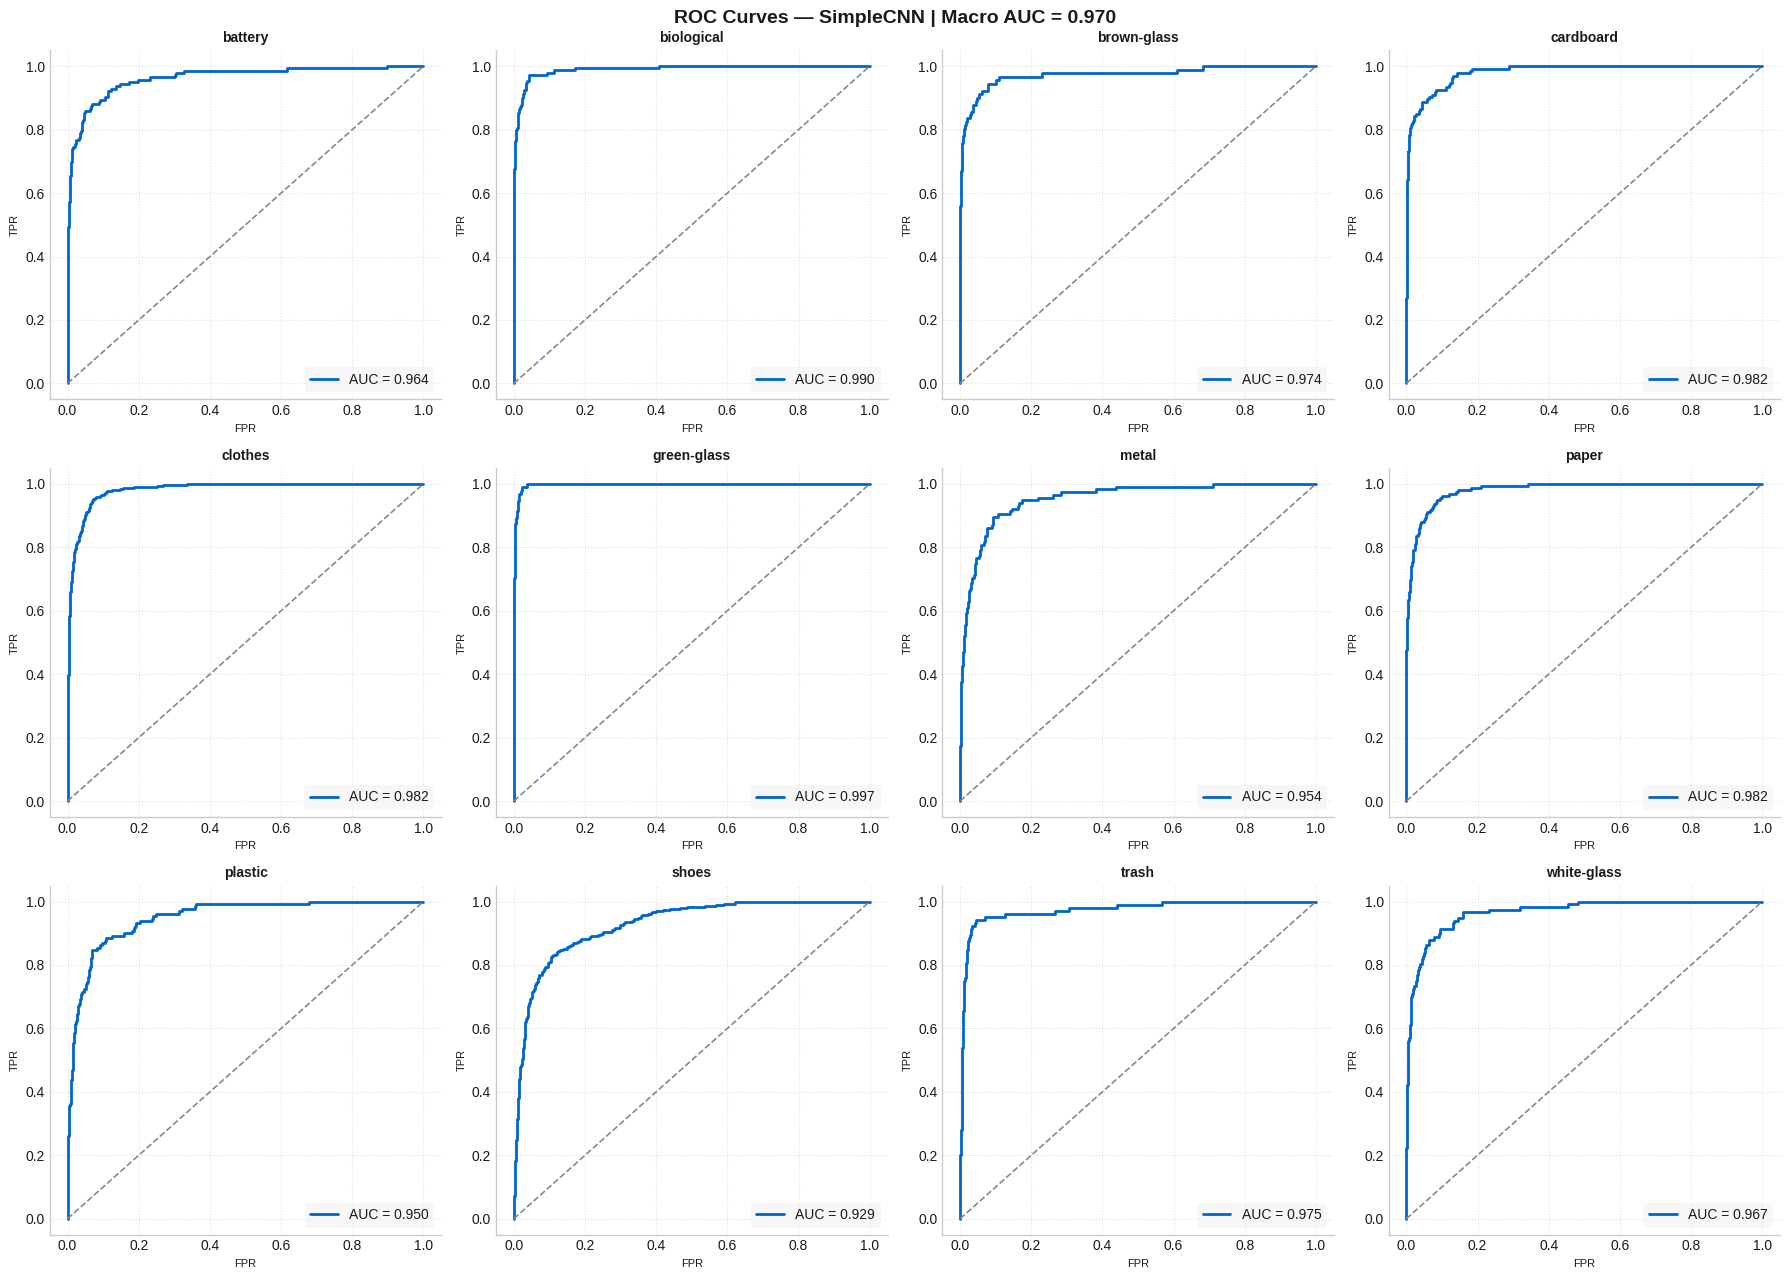

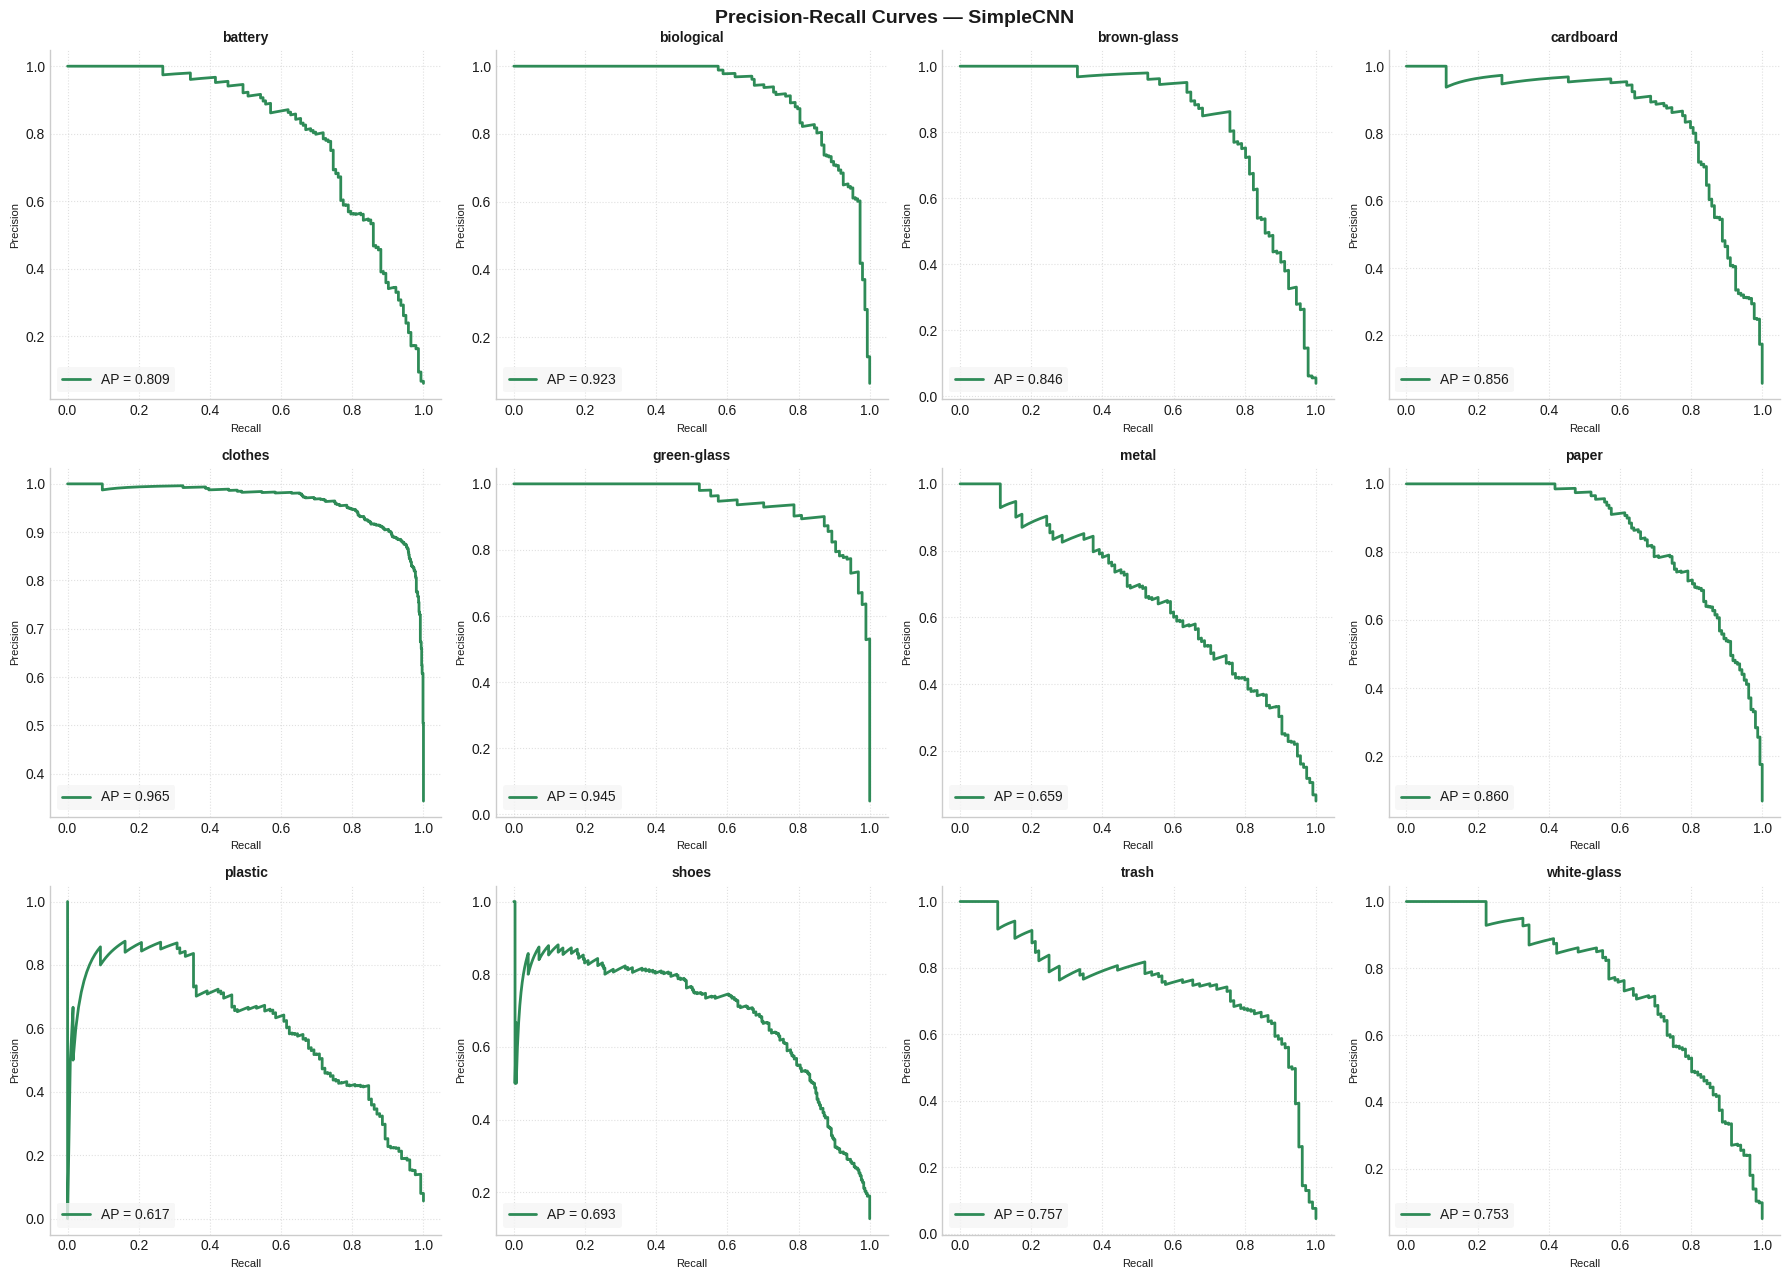


Training VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 118s 296ms/step - accuracy: 0.6006 - loss: 1.7533 - val_accuracy: 0.7757 - val_loss: 1.1941
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 111s 252ms/step - accuracy: 0.7455 - loss: 1.3799 - val_accuracy: 0.8238 - val_loss: 1.0844
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 86s 252ms/step - accuracy: 0.7769 - loss: 1.2800 - val_accuracy: 0.8436 - val_loss: 1.0440
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 78s 230ms/step - accuracy: 0.8014 - loss: 1.2306 - val_accuracy: 0.8474 - val_loss: 1.0213
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 78s 229ms/step - accuracy: 0.8111 - loss: 1.1986 - val_accuracy: 0.8492 - val_loss: 1.0066
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 78s 228ms/step - accuracy: 0.8196 - loss: 1.1716 - val_accuracy: 0.8681 - val_loss: 0.9788
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 78s 229ms/step - accuracy: 0.8269 - loss: 1.1494 - val_accuracy: 0.8659 - val_loss: 0.9799
Epoch 8/20
340

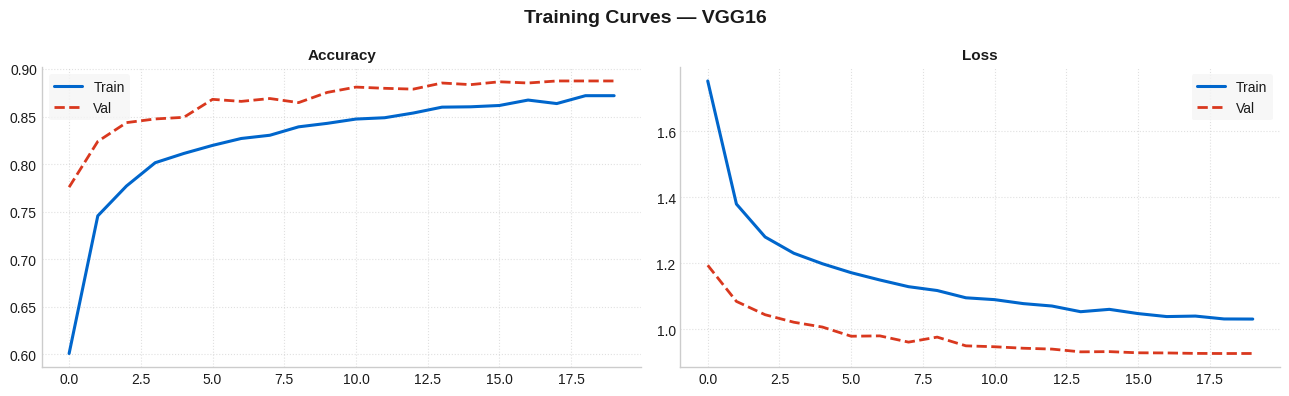


── VGG16 ──
              precision    recall  f1-score   support

     battery       0.86      0.90      0.88       142
  biological       0.91      0.93      0.92       148
 brown-glass       0.74      0.77      0.76        91
   cardboard       0.76      0.82      0.79       134
     clothes       0.97      0.95      0.96       799
 green-glass       0.90      0.87      0.89        94
       metal       0.64      0.72      0.68       115
       paper       0.87      0.74      0.80       158
     plastic       0.73      0.69      0.71       130
       shoes       0.90      0.94      0.92       297
       trash       0.85      0.85      0.85       104
 white-glass       0.73      0.73      0.73       116

    accuracy                           0.87      2328
   macro avg       0.82      0.83      0.82      2328
weighted avg       0.87      0.87      0.87      2328



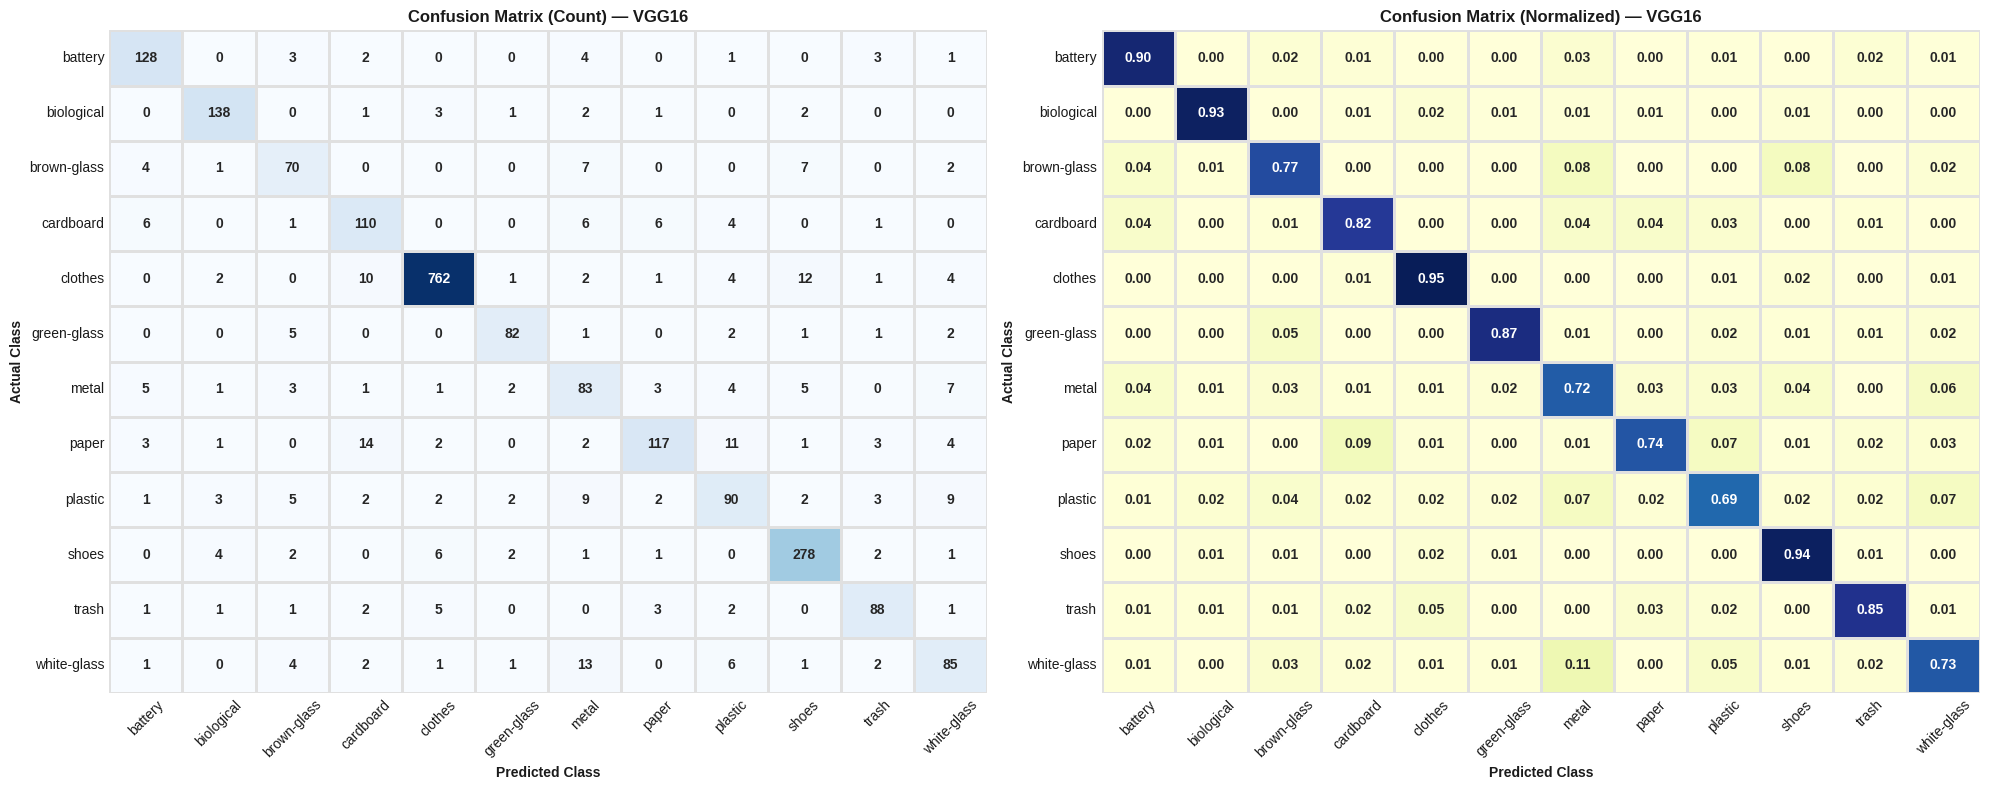

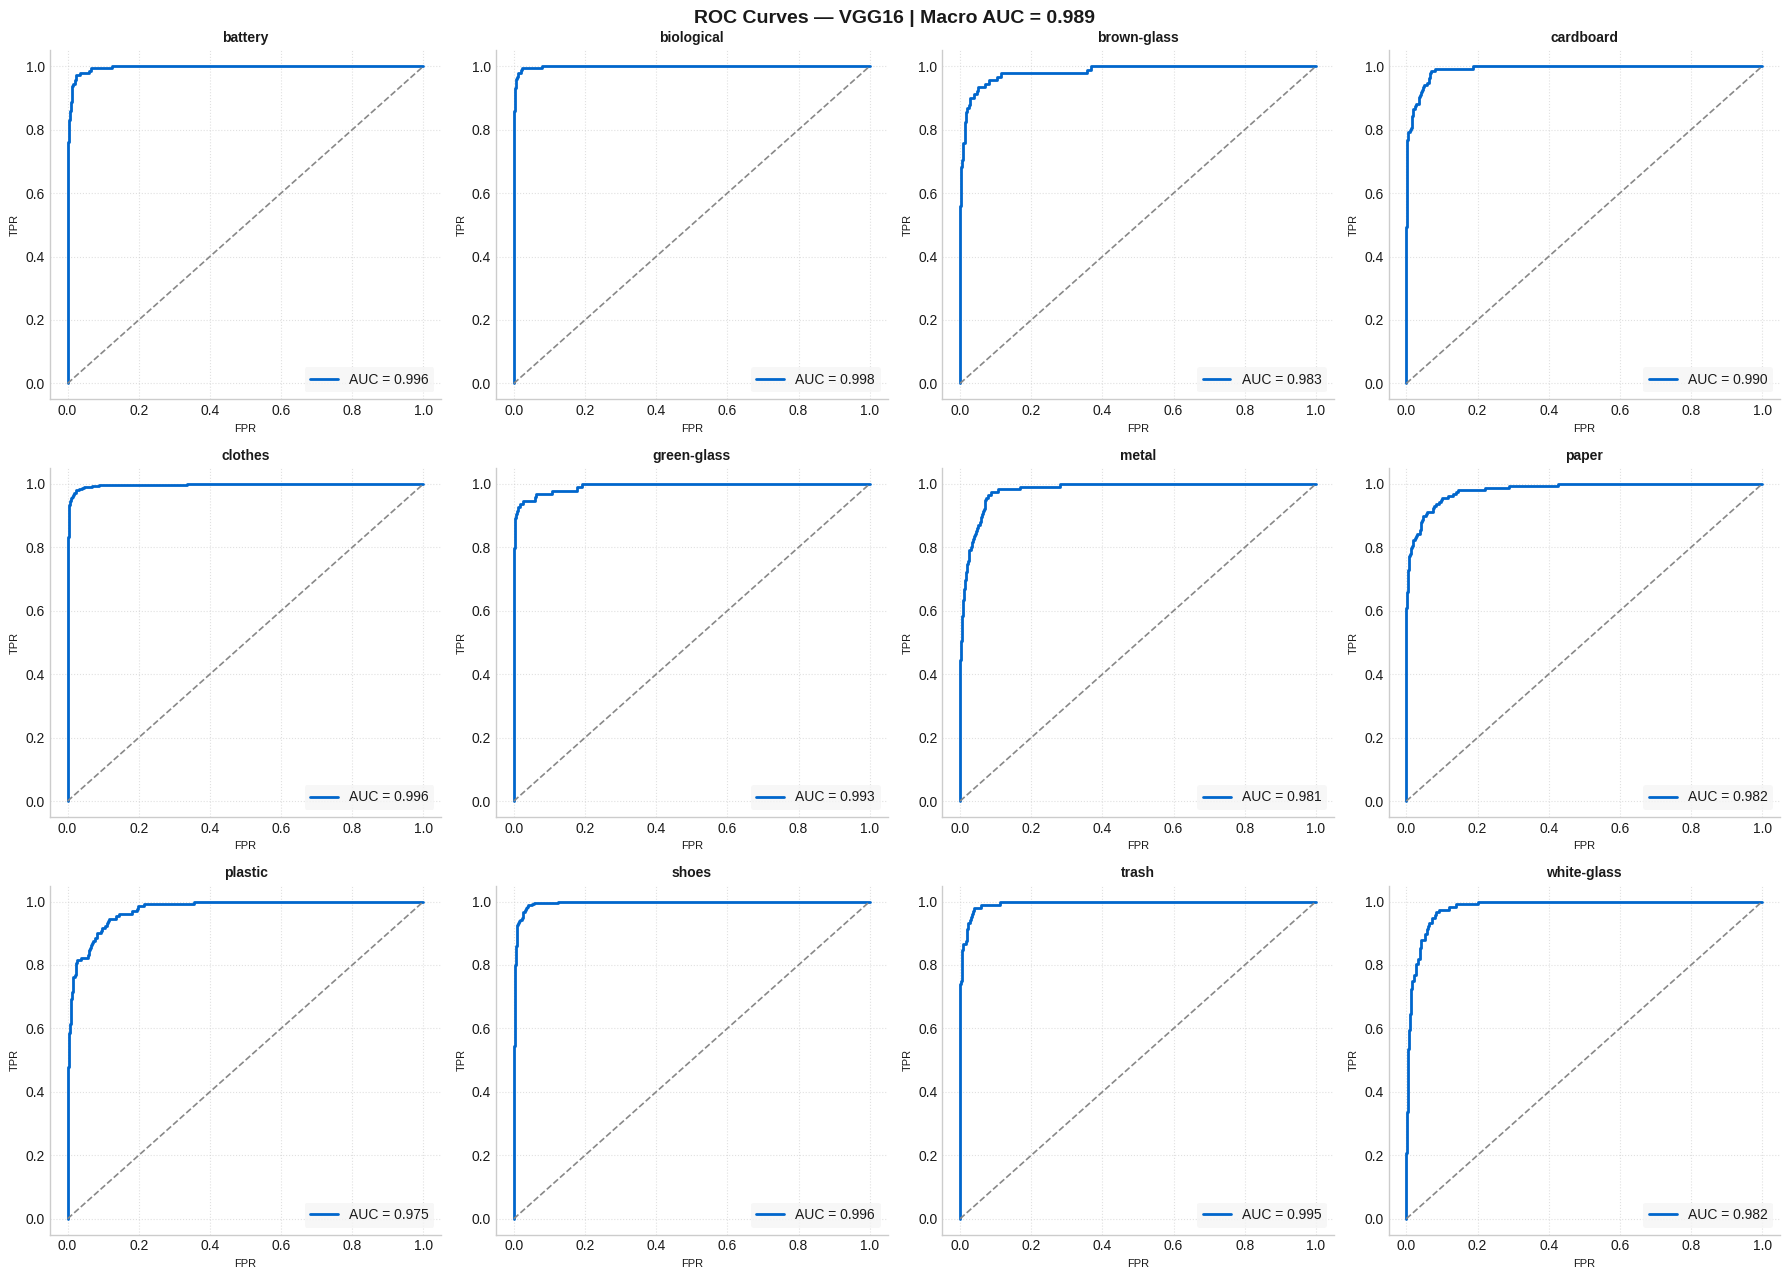

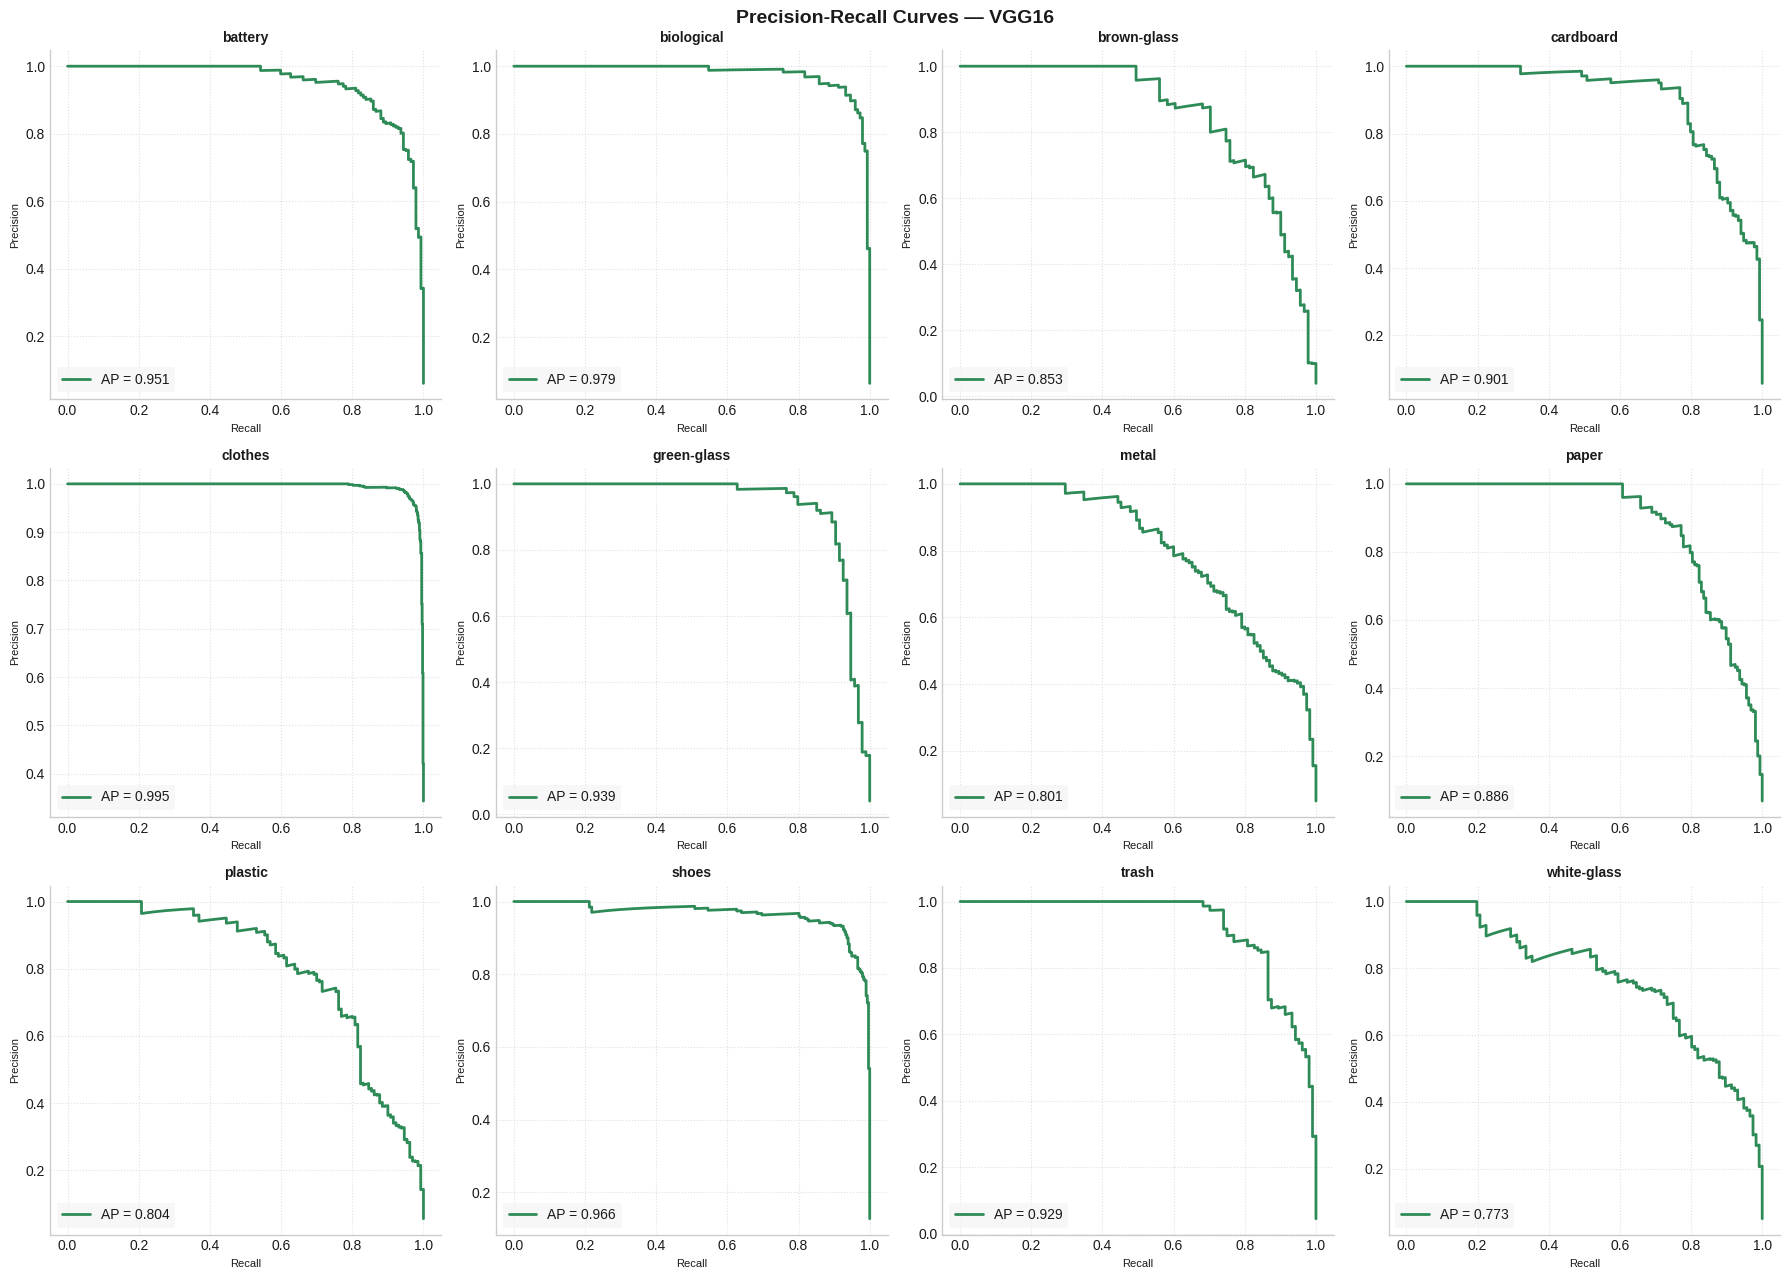


Training VGG19
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 104s 295ms/step - accuracy: 0.5662 - loss: 1.8359 - val_accuracy: 0.7452 - val_loss: 1.2555
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 97s 284ms/step - accuracy: 0.7119 - loss: 1.4684 - val_accuracy: 0.7920 - val_loss: 1.1408
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 97s 285ms/step - accuracy: 0.7449 - loss: 1.3707 - val_accuracy: 0.8083 - val_loss: 1.0910
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 97s 284ms/step - accuracy: 0.7644 - loss: 1.3277 - val_accuracy: 0.8187 - val_loss: 1.0835
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 97s 284ms/step - accuracy: 0.7738 - loss: 1.2986 - val_accuracy: 0.8298 - val_loss: 1.0582
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 96s 283ms/step - accuracy: 0.7877 - loss: 1.2597 - val_accuracy: 0.8281 - val_loss: 1.0543
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 97s 285ms/step - accuracy: 0.7931 - loss: 1.2457 - val_accuracy: 0.8474 - val_loss: 1.0190
Epoch 8/20
340/

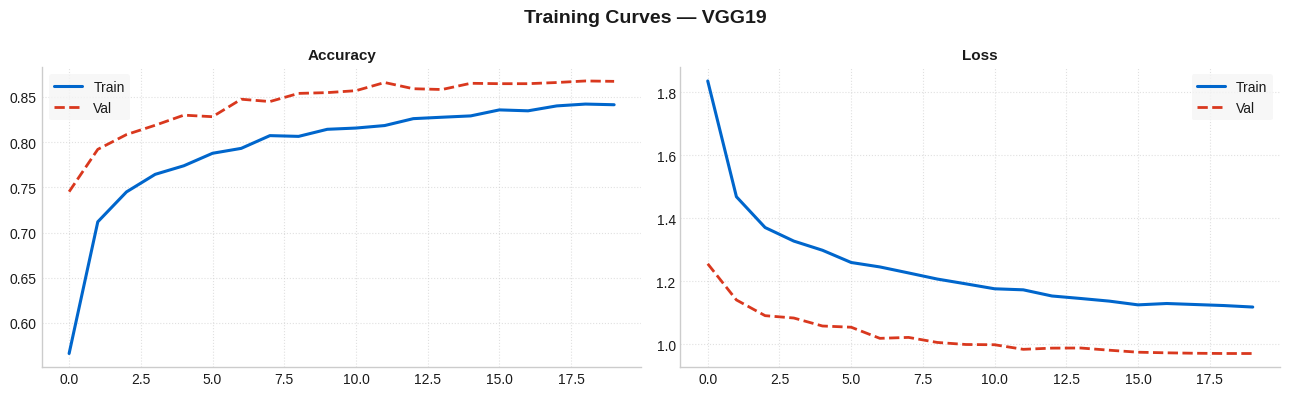


── VGG19 ──
              precision    recall  f1-score   support

     battery       0.84      0.86      0.85       142
  biological       0.86      0.91      0.89       148
 brown-glass       0.73      0.77      0.75        91
   cardboard       0.71      0.81      0.76       134
     clothes       0.98      0.95      0.97       799
 green-glass       0.91      0.83      0.87        94
       metal       0.69      0.70      0.70       115
       paper       0.80      0.72      0.76       158
     plastic       0.66      0.63      0.64       130
       shoes       0.88      0.94      0.91       297
       trash       0.83      0.76      0.79       104
 white-glass       0.65      0.61      0.63       116

    accuracy                           0.85      2328
   macro avg       0.79      0.79      0.79      2328
weighted avg       0.85      0.85      0.85      2328



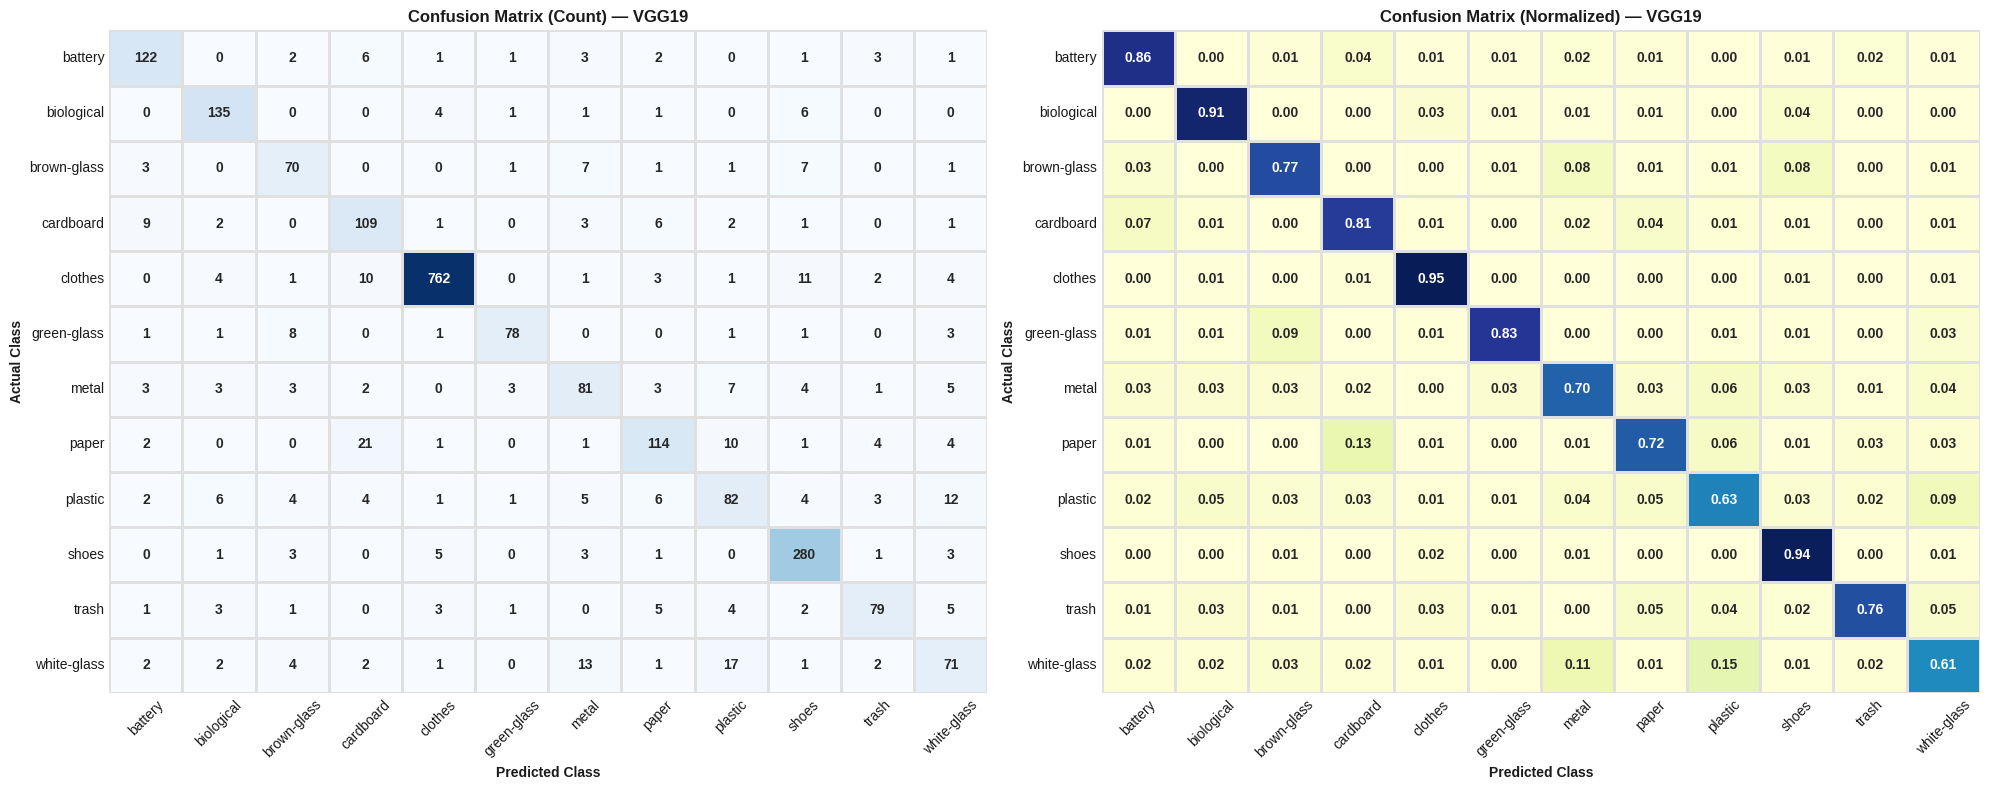

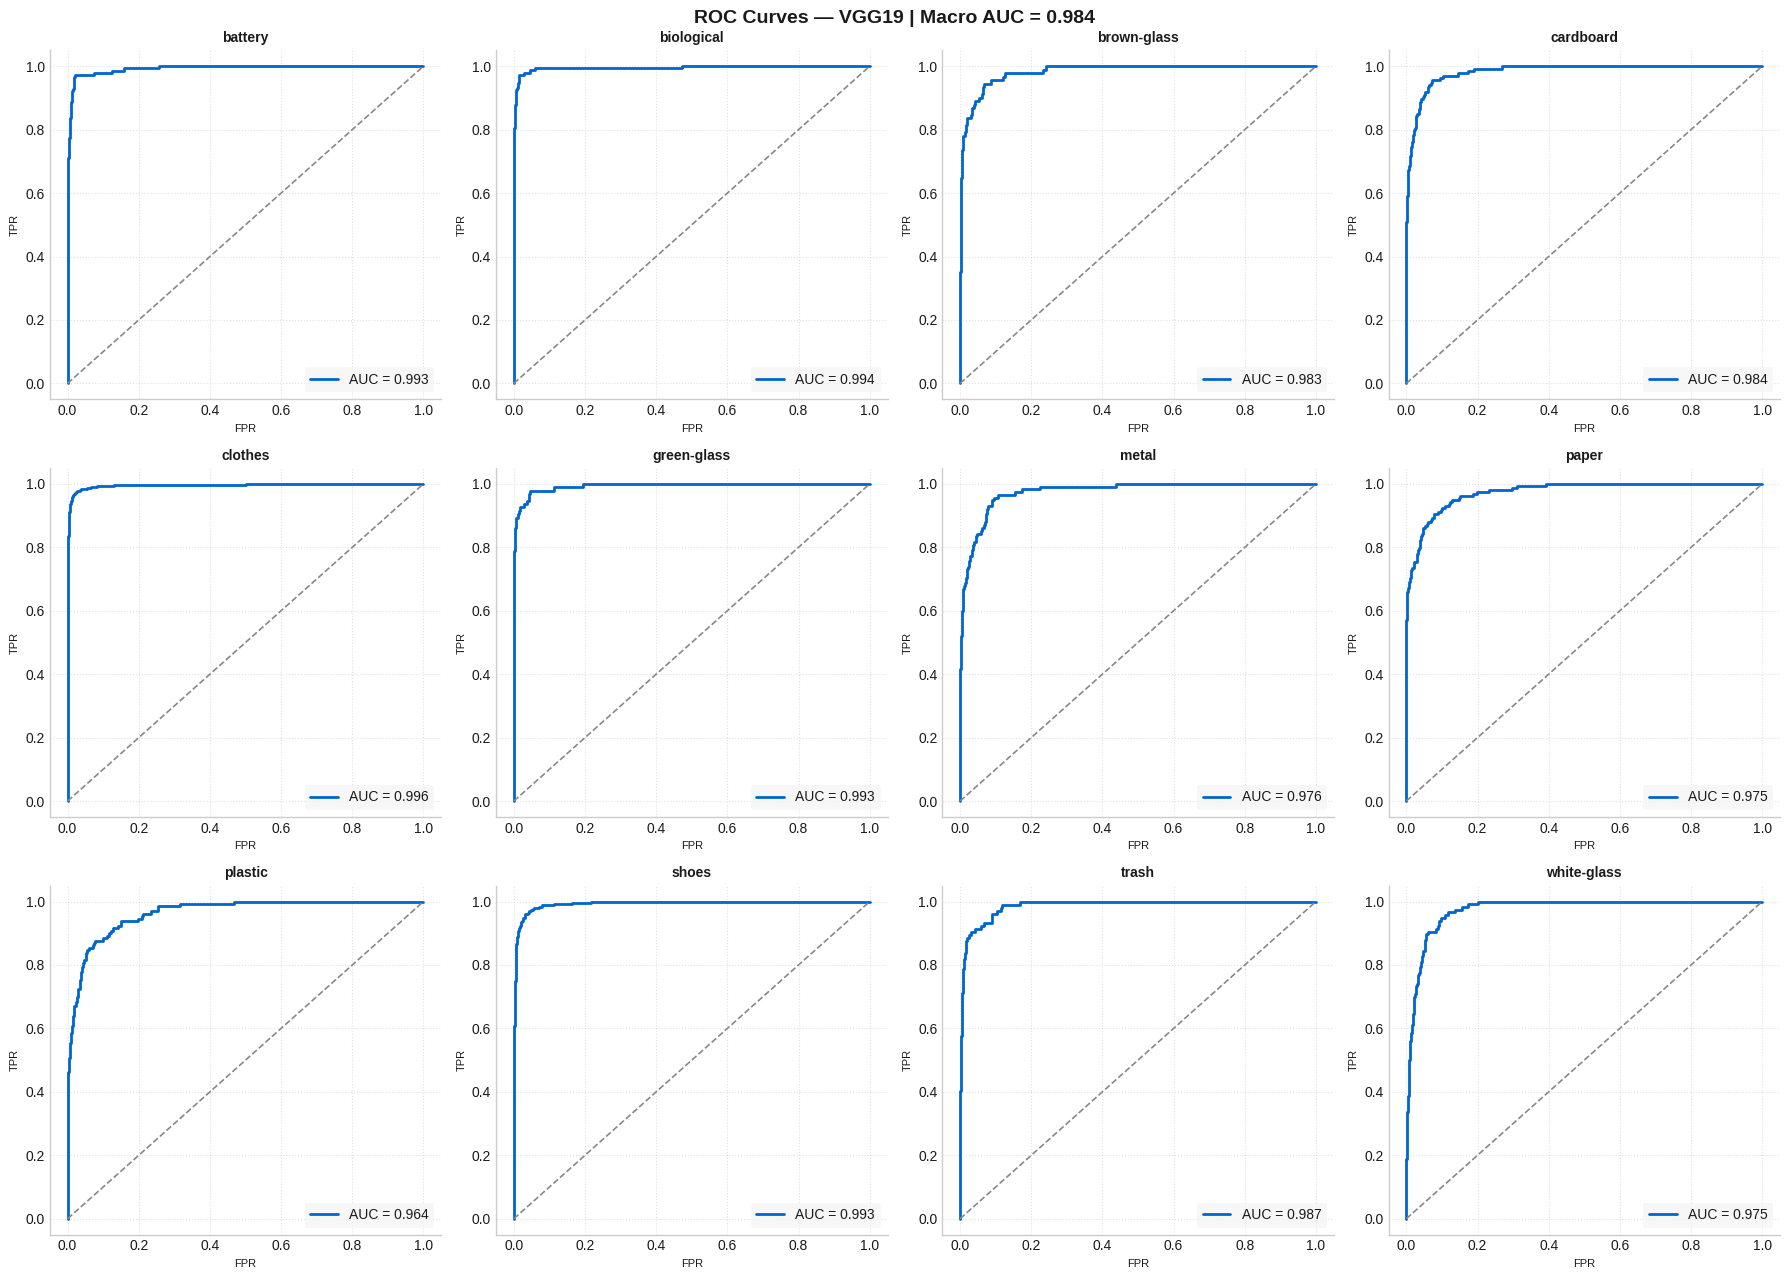

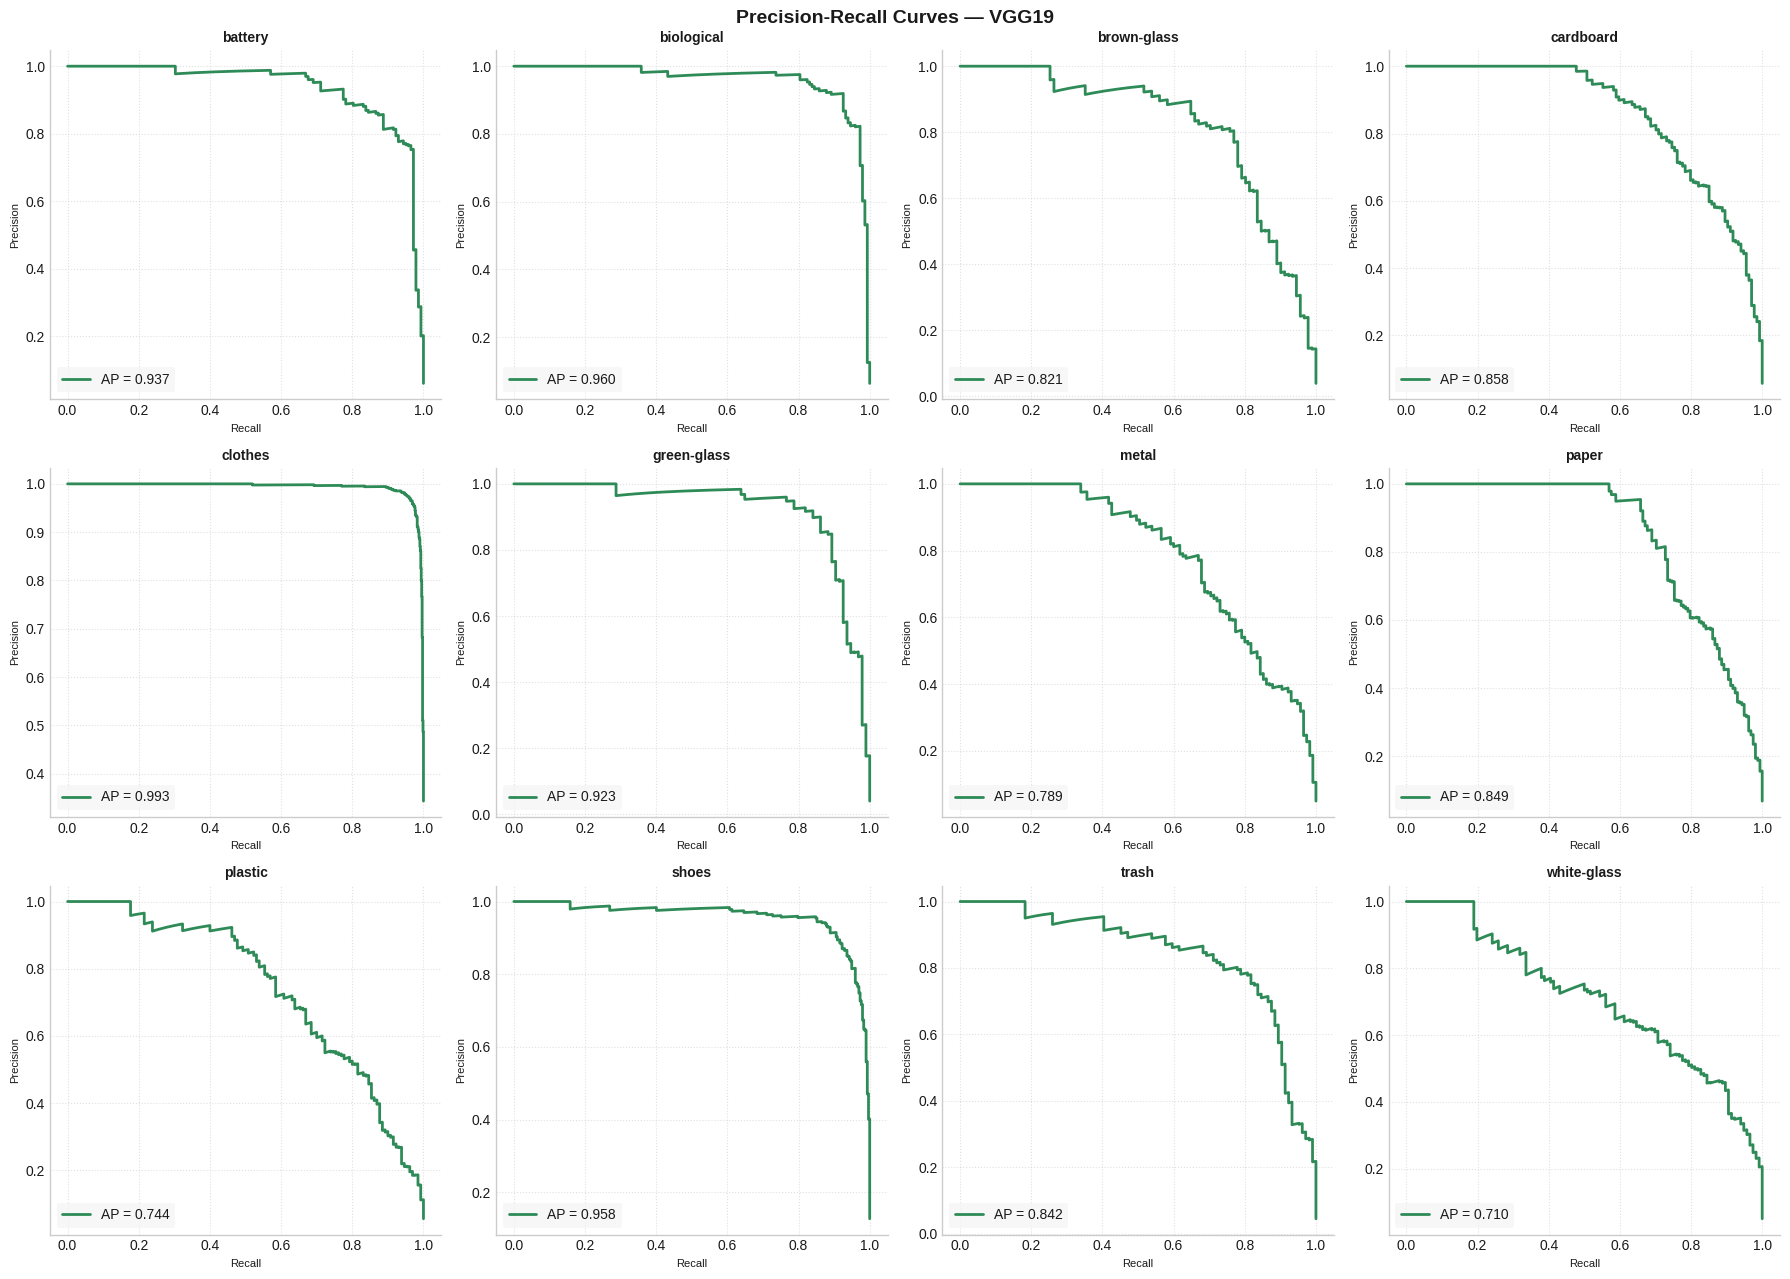


Training MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 80s 180ms/step - accuracy: 0.8246 - loss: 1.2077 - val_accuracy: 0.9145 - val_loss: 0.8626
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9017 - loss: 0.9783 - val_accuracy: 0.9231 - val_loss: 0.8180
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9192 - loss: 0.9195 - val_accuracy: 0.9317 - val_loss: 0.7999
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy: 0.9326 - loss: 0.8812 - val_accuracy: 0.9441 - val_loss: 0.7879
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.9438 - loss: 0.8565 - val_accuracy: 0.9416 - val_loss: 0.7886
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9496 - loss: 0.8275 - val_accuracy: 0.9441 - val_loss: 0.7772
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9561 - loss: 0.8122 - val_accuracy: 0.9373 - val_loss: 0.7726
Epoch 8/20
340/340

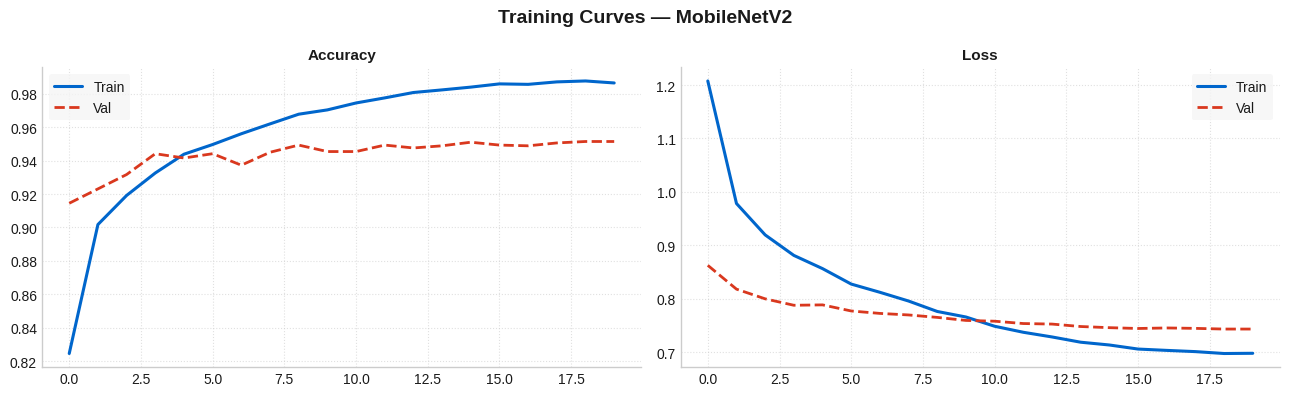


── MobileNetV2 ──
              precision    recall  f1-score   support

     battery       0.97      0.99      0.98       142
  biological       0.98      0.98      0.98       148
 brown-glass       0.94      0.85      0.89        91
   cardboard       0.96      0.90      0.93       134
     clothes       0.99      0.99      0.99       799
 green-glass       0.95      0.91      0.93        94
       metal       0.84      0.94      0.89       115
       paper       0.93      0.95      0.94       158
     plastic       0.87      0.91      0.89       130
       shoes       0.95      0.97      0.96       297
       trash       0.95      0.96      0.96       104
 white-glass       0.88      0.81      0.84       116

    accuracy                           0.95      2328
   macro avg       0.93      0.93      0.93      2328
weighted avg       0.95      0.95      0.95      2328



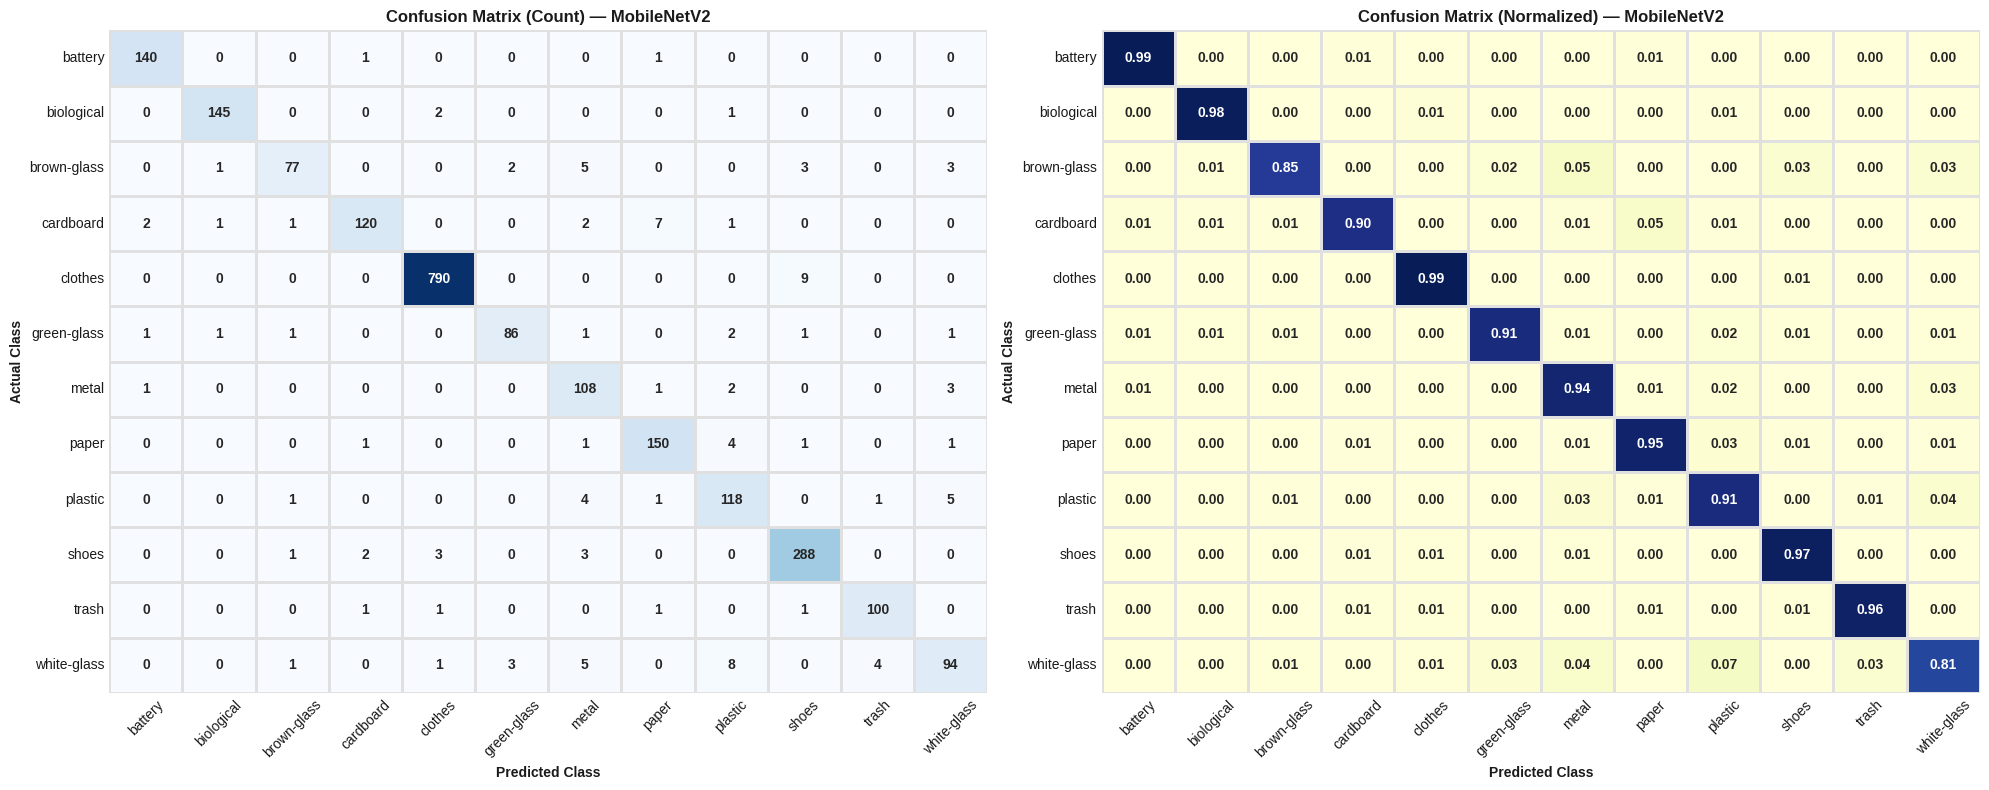

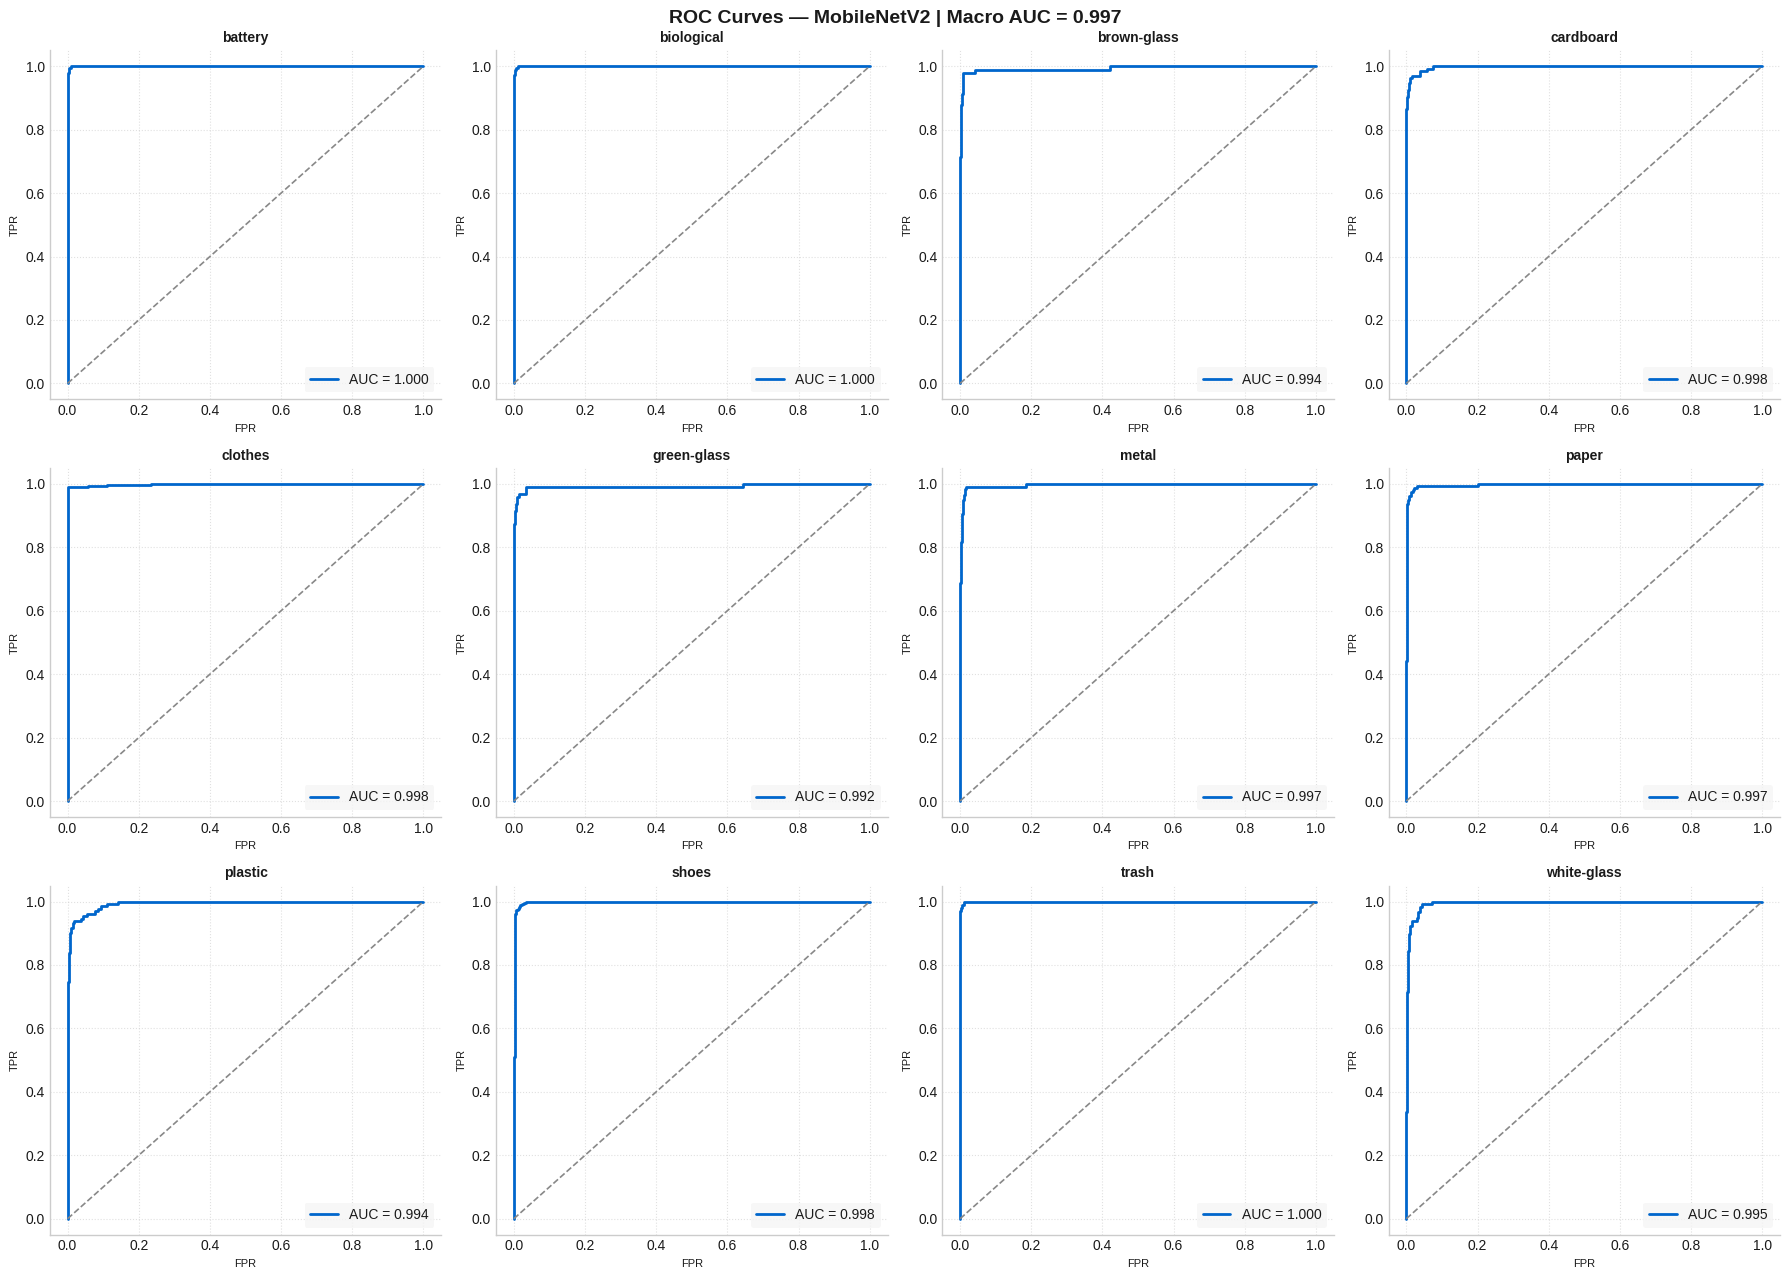

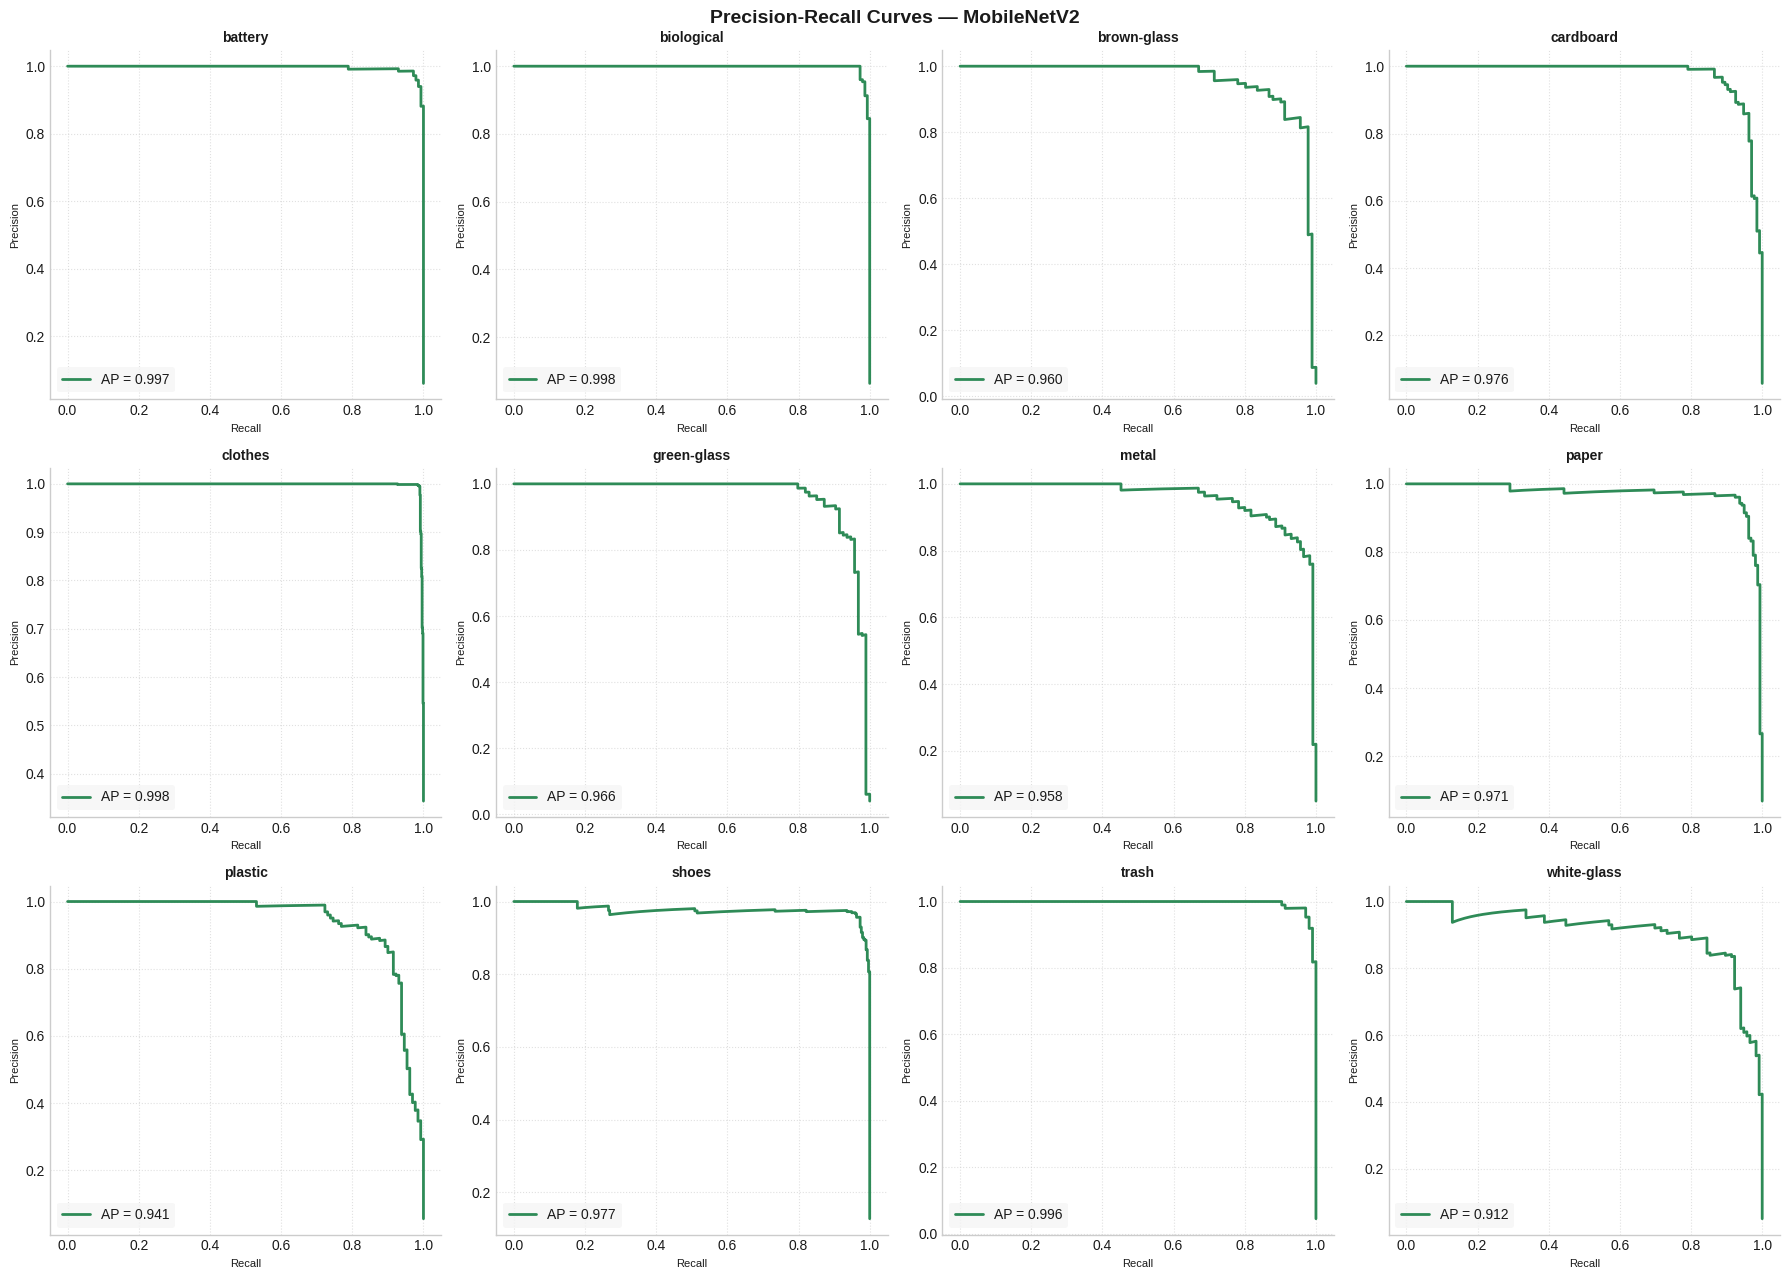


Training EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 94s 206ms/step - accuracy: 0.8956 - loss: 0.9831 - val_accuracy: 0.9626 - val_loss: 0.7380
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - accuracy: 0.9536 - loss: 0.8069 - val_accuracy: 0.9661 - val_loss: 0.7206
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 36s 107ms/step - accuracy: 0.9654 - loss: 0.7694 - val_accuracy: 0.9686 - val_loss: 0.7162
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9755 - loss: 0.7416 - val_accuracy: 0.9699 - val_loss: 0.7070
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.9787 - loss: 0.7246 - val_accuracy: 0.9703 - val_loss: 0.7029
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.9818 - loss: 0.7119 - val_accuracy: 0.9725 - val_loss: 0.6988
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.9847 - loss: 0.7018 - val_accuracy: 0.9716 - val_loss: 0.6964
Epoch 8

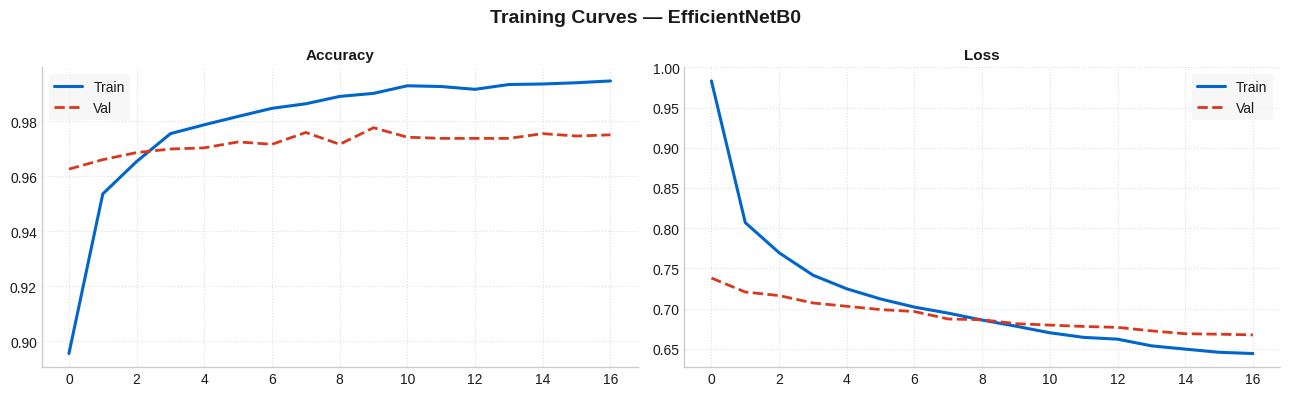


── EfficientNetB0 ──
              precision    recall  f1-score   support

     battery       0.99      0.99      0.99       142
  biological       0.98      0.99      0.99       148
 brown-glass       0.90      0.95      0.92        91
   cardboard       0.99      0.96      0.97       134
     clothes       1.00      0.99      0.99       799
 green-glass       0.99      0.93      0.96        94
       metal       0.91      0.93      0.92       115
       paper       0.96      0.97      0.97       158
     plastic       0.89      0.94      0.91       130
       shoes       0.97      0.99      0.98       297
       trash       0.97      0.95      0.96       104
 white-glass       0.92      0.91      0.91       116

    accuracy                           0.97      2328
   macro avg       0.96      0.96      0.96      2328
weighted avg       0.97      0.97      0.97      2328



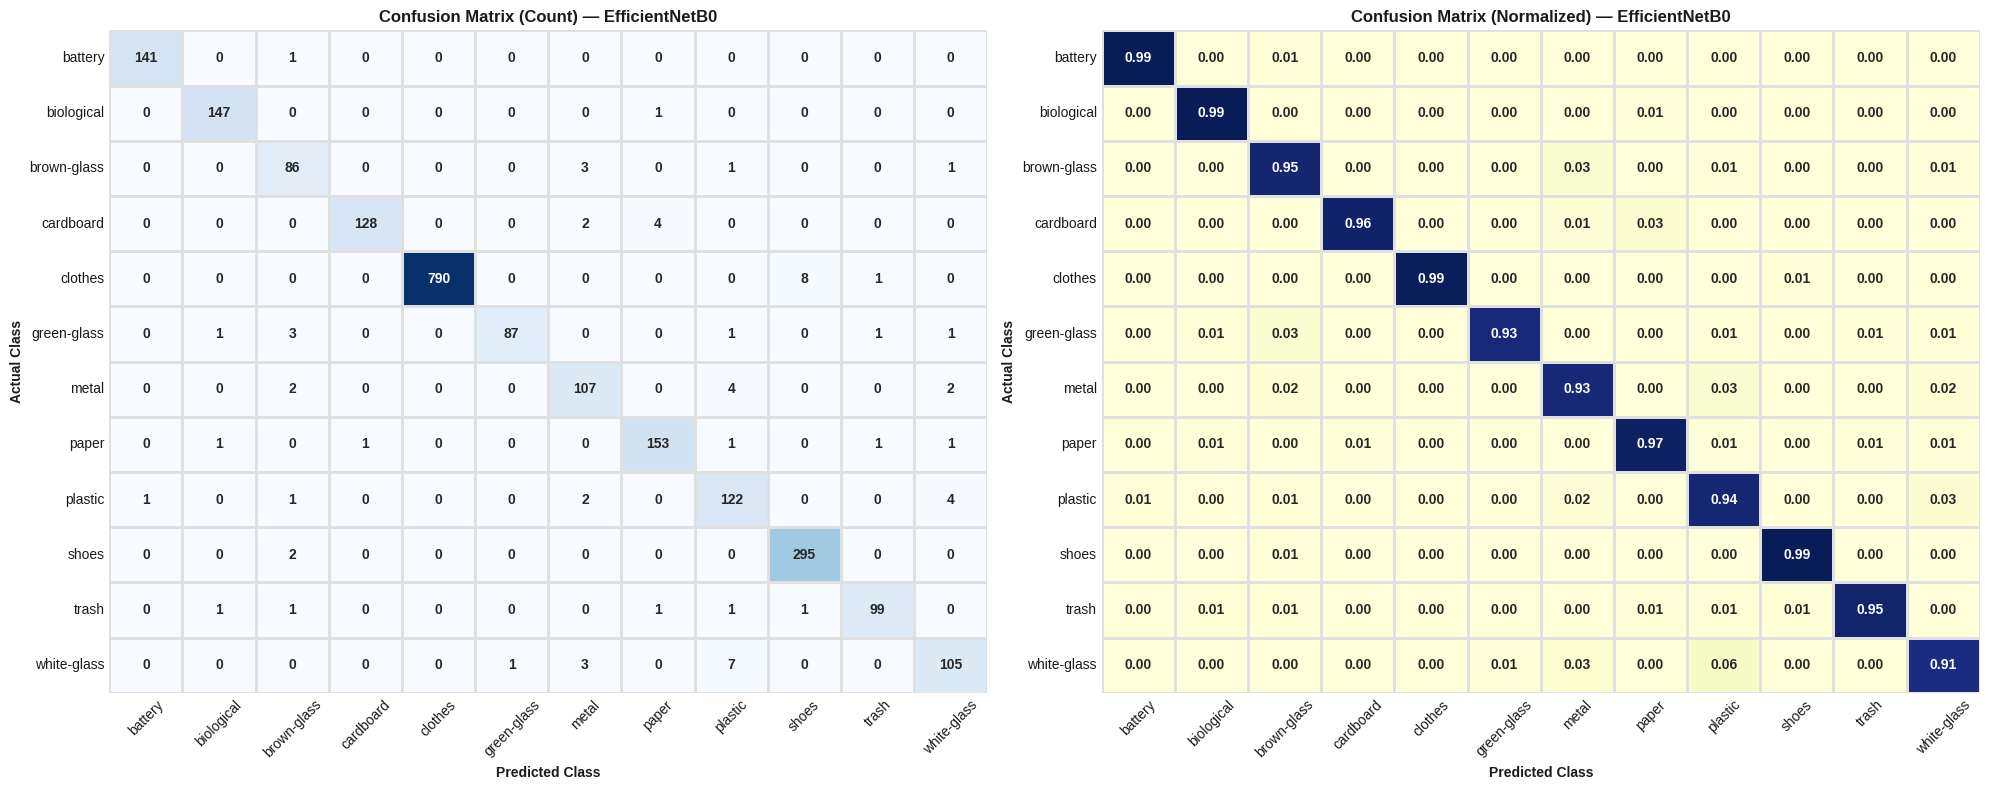

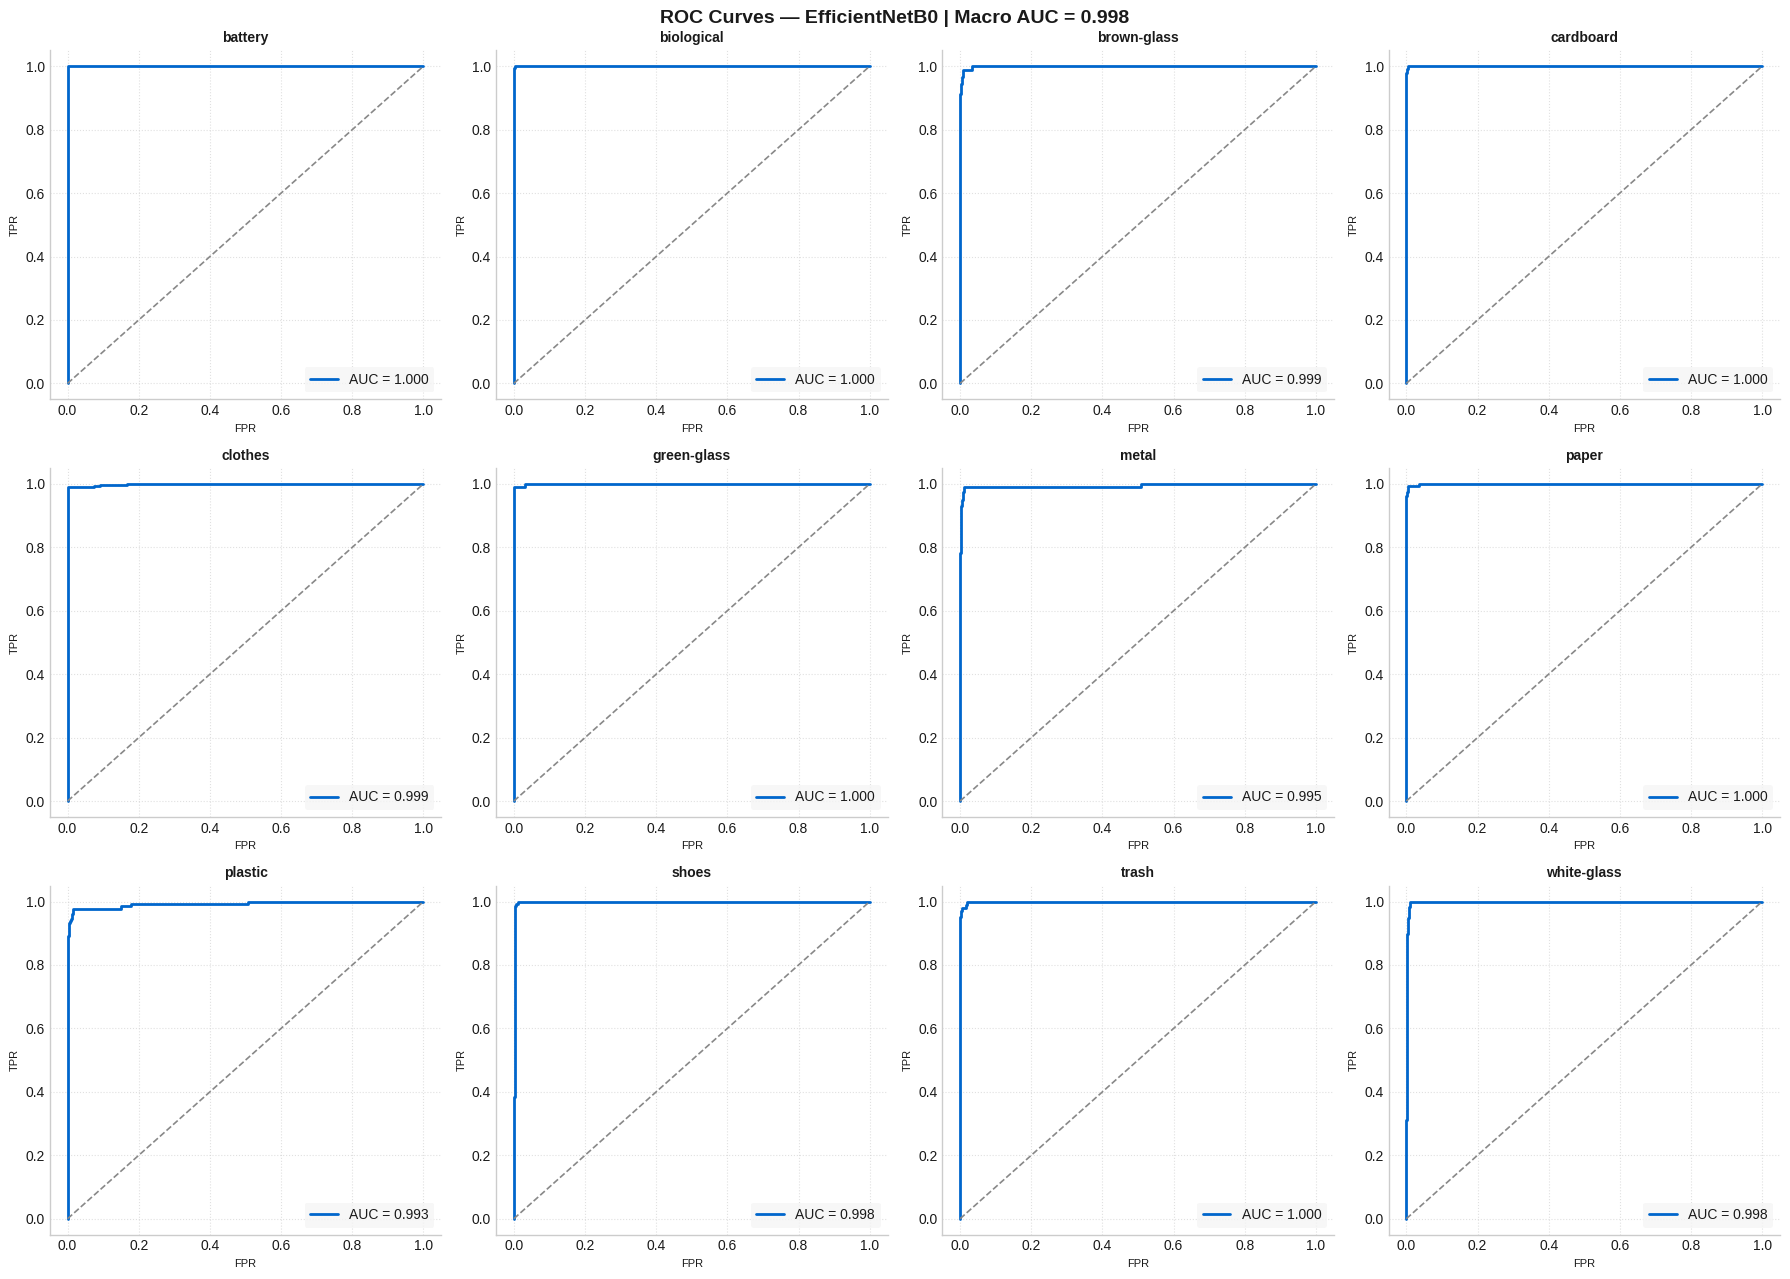

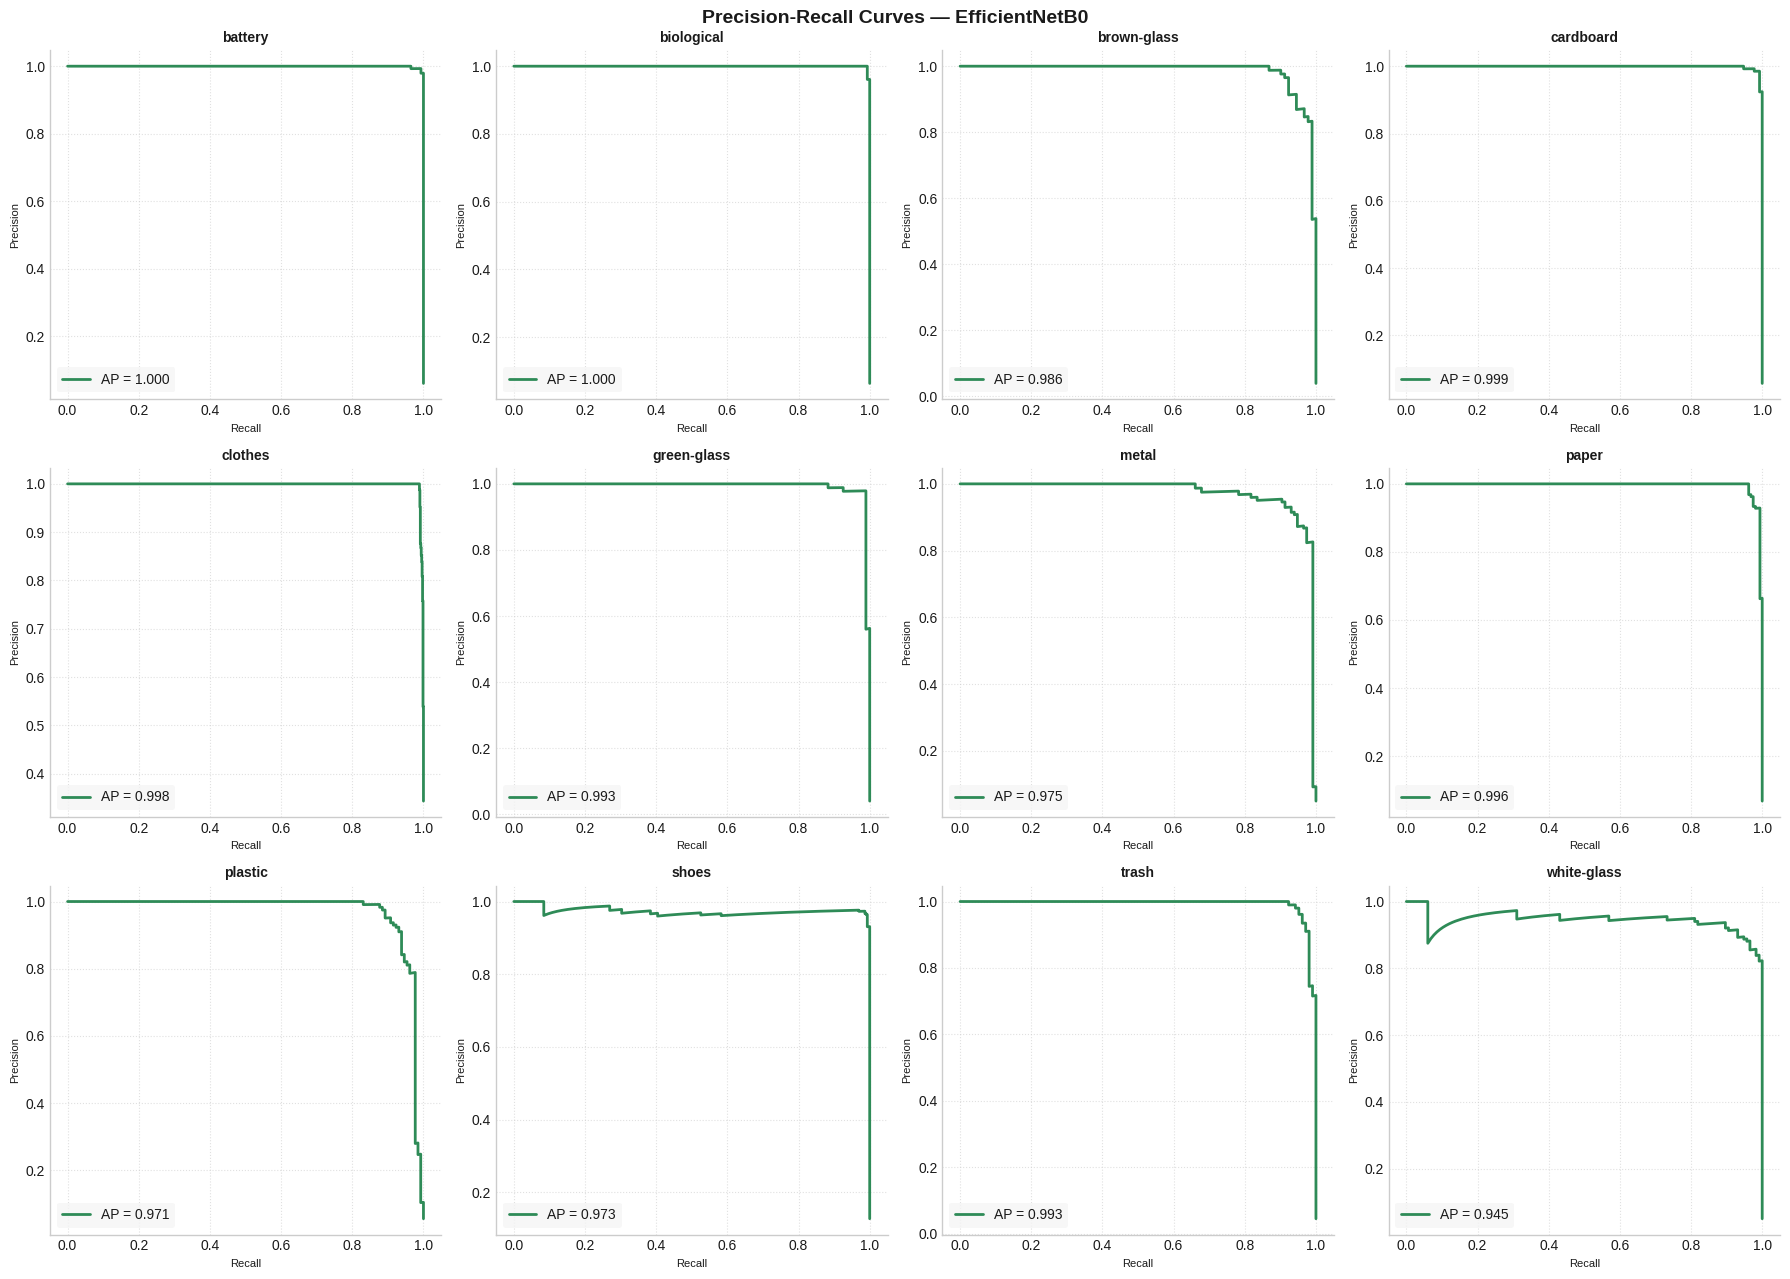


Training EfficientNetB1
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 106s 218ms/step - accuracy: 0.8940 - loss: 0.9907 - val_accuracy: 0.9661 - val_loss: 0.7195
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.9537 - loss: 0.8066 - val_accuracy: 0.9652 - val_loss: 0.7205
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - accuracy: 0.9659 - loss: 0.7686 - val_accuracy: 0.9665 - val_loss: 0.7063
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - accuracy: 0.9723 - loss: 0.7527 - val_accuracy: 0.9695 - val_loss: 0.6993
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 0.9757 - loss: 0.7363 - val_accuracy: 0.9751 - val_loss: 0.6933
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9812 - loss: 0.7180 - val_accuracy: 0.9721 - val_loss: 0.6909
Epoch 7/20
322/340 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9871 - loss: 0.7067

In [ ]:
# Train all baselines
results, times = {}, {}
for name, build_fn in [("SimpleCNN",simple_cnn),("VGG16",vgg16_model),("VGG19",vgg19_model),("MobileNetV2",mobilenet_model),("EfficientNetB0",efficientnet_model), ("EfficientNetB1",efficientnetb1_model),("EfficientNetB2",efficientnetb2_model),("EfficientNetB3",efficientnetb3_model),("EfficientNetB4",efficientnetb4_model),("EfficientNetB5",efficientnetb5_model)]:
    print(f"\n{'='*50}\nTraining {name}\n{'='*50}")
    m = build_fn()
    m.compile(optimizer=cosine_opt(), loss=std_loss, metrics=["accuracy"])
    t0 = time.time()
    hist = m.fit(train_ds, epochs=CFG.B_EP, validation_data=val_ds,
                 class_weight=class_weights, callbacks=callbacks(name), verbose=1)
    times[name] = time.time() - t0
    plot_curves(hist.history, name)
    yt,yp,yt_oh,yp_pr,rep = evaluate(m, test_ds, name)
    plot_cm(yt, yp, name)
    roc_auc = plot_roc(yt_oh, yp_pr, name)
    plot_pr(yt_oh, yp_pr, name)
    results[name] = {"model":m,"hist":hist.history,"yt":yt,"yp":yp,
                     "yt_oh":yt_oh,"yp_pr":yp_pr,"rep":rep,"roc":roc_auc}

In [ ]:
# Bar comparison chart with downward-oriented X-axis labels
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Model Comparison", fontsize=15, fontweight="bold", y=0.98)

metrics = [
    ("Test Acc", "Test Acc"),
    ("Macro F1", "Macro F1"),
    ("Macro AUC", "ROC AUC"),
    ("Params (M)", "Params (M)"),
    ("Train Time(s)", "Train Time(s)"),
    ("Weighted F1", "Weighted F1"),
]

# Modern publication palette
clrs = ["#2563EB", "#059669", "#D97706", "#DC2626"]

for ax, (col, title) in zip(axes.flatten(), metrics):
    bars = ax.bar(
        comp["Model"],
        comp[col],
        color=clrs,
        edgecolor="#1E293B",
        linewidth=0.8,
        width=0.55,
    )
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)

    # Set X-axis tick label rotation to -90 degrees (downward vertical)
    ax.tick_params(axis="x", rotation=-90, labelsize=9)

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.margins(y=0.22)  # Additional spacing at top for value annotations

    for b, v in zip(bars, comp[col]):
        val_str = (
            f"{v:.1f}"
            if "Time" in col
            else (f"{v:.2f}" if "Params" in col else f"{v:.4f}")
        )
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + (max(comp[col]) * 0.015),
            val_str,
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="semibold",
        )

plt.tight_layout()
plt.savefig(f"{CFG.OUT}/comparison_chart.png", dpi=300)
plt.show()

In [ ]:
# ── 12. INFERENCE ────────────────────────────────────────────
def run_inference(model, df, name, n=16):
    idxs = random.sample(range(len(df)), n)
    fig, axes = plt.subplots(4,4,figsize=(14,14))
    for ax, idx in zip(axes.flatten(), idxs):
        path = df.iloc[idx]["path"]
        yt   = df.iloc[idx]["label_idx"]
        img,_ = load_img(path, 0)
        pred  = model.predict(tf.expand_dims(img,0), verbose=0)[0]
        yp, conf = np.argmax(pred), np.max(pred)
        ok = (yt == yp)
        ax.imshow(plt.imread(path))
        ax.set_title(f"{'✓' if ok else '✗'} {CFG.CLASSES[yt]}\n→{CFG.CLASSES[yp]} {conf:.2f}",
                     fontsize=8, color="green" if ok else "red")
        ax.axis("off")
    plt.suptitle(f"Inference — {name}", fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{CFG.OUT}/inference_{name}.png",dpi=120); plt.show()



#run_inference(hybrid, test_df, "HybridGarbageNet")
run_inference(results["SimpleCNN"]["model"], test_df, "SimpleCNN")
run_inference(results["MobileNetV2"]["model"], test_df, "MobileNetV2")
run_inference(results["VGG16"]["model"], test_df, "VGG16")
run_inference(results["VGG19"]["model"], test_df, "VGG19")
run_inference(results["EfficientNetB0"]["model"], test_df, "EfficientNetB0")
run_inference(results["EfficientNetB1"]["model"], test_df, "EfficientNetB1")
run_inference(results["EfficientNetB2"]["model"], test_df, "EfficientNetB2")
run_inference(results["EfficientNetB3"]["model"], test_df, "EfficientNetB3")
run_inference(results["EfficientNetB4"]["model"], test_df, "EfficientNetB4")
run_inference(results["EfficientNetB5"]["model"], test_df, "EfficientNetB5")

In [ ]:
# ── 13. SAVE MODELS ──────────────────────────────────────────
for name, r in results.items():
    r["model"].save(f"{CFG.OUT}/{name}_final.keras")
    print(f"Saved: {name}")

print(f"\n✅ Done. All outputs in: {CFG.OUT}")
print(f"🏆 Winner: {best} | Test Acc: {comp.loc[comp.Model==best,'Test Acc'].values[0]:.4f}")